# Capstone Project — Heart Disease Prediction with Interactive ML Dashboard

This dashboard builds and evaluates a complete machine learning workflow on the Heart Disease Prediction dataset (Fedesoriano, Kaggle). It covers Exploratory Data Analysis (EDA), data preprocessing, classification and clustering — using Random Forest to predict the presence of heart disease (binary: 0/1) based on patient clinical attributes such as age, cholesterol, chest pain type, and ST slope. Model performance is evaluated using accuracy, precision, recall, F1-score, ROC curves, and confusion matrices. Feature importance and interpretability tools are applied to understand which clinical factors drive predictions the most, providing actionable insights for both technical practitioners and non-technical stakeholders.


## **Attribute Information**

**Age** : age of the patient [years]

**Sex** : sex of the patient [M: Male, F: Female]

**ChestPainType** : chest pain type [TA: Typical Angina, ATA: Atypical Angina, : Non-Anginal Pain, ASY: Asymptomatic]

**RestingBP** : resting blood pressure [mm Hg]   

**Cholesterol** : serum cholesterol [mm/dl]   

**FastingBS** : fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]   

**RestingECG** : resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]   

**MaxHR** : maximum heart rate achieved [Numeric value between 60 and 202]   

**ExerciseAngina** : exercise-induced angina [Y: Yes, N: No]   

**Oldpeak: oldpeak**  = ST [Numeric value measured in depression]   

**ST_Slope** : the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]   

**HeartDisease** : output class [1: heart disease, 0: Normal]   

## **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, classification_report,accuracy_score,
                             precision_score,recall_score,f1_score,roc_curve, auc, precision_recall_curve)
from datetime import datetime, timedelta
from sklearn.decomposition import PCA
from sklearn.inspection import PartialDependenceDisplay
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats
import shap
import dash
from dash import dcc, html, dash_table , callback
from dash.dependencies import Input, Output, State
from lime import lime_tabular
import glob
import base64
import io
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported")

Libraries imported


c:\Users\eng_b\miniconda3\envs\Bassem\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


## **Loading The Dataset**

In [2]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
csv_file = glob.glob(f"{path}/*.csv")[0]
df = pd.read_csv(csv_file)

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [5]:
# Checking if there is missing values to deal with before data preprocessing
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

**There is no missing values to deal with**

## **Data Preprocessing**

**Prepare data for ML and visualizations by converting date columns, extract useful date features, encode categoricals.**

In [6]:
# Checking the categorical columns to deal with them before data preprocessing

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


**Encoding data the categorical date using Label Encoding**

In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

**Label encoding is used over one-hot encoding not to increase the features too much for better and easier visualizations.**

In [8]:
# Showing the first 5 rows of the dataset after encoding the categorical columns
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


**Before/After encoding comparison**

*Show before and after label encoding for each categorical column to visualize what encoding did to each category*

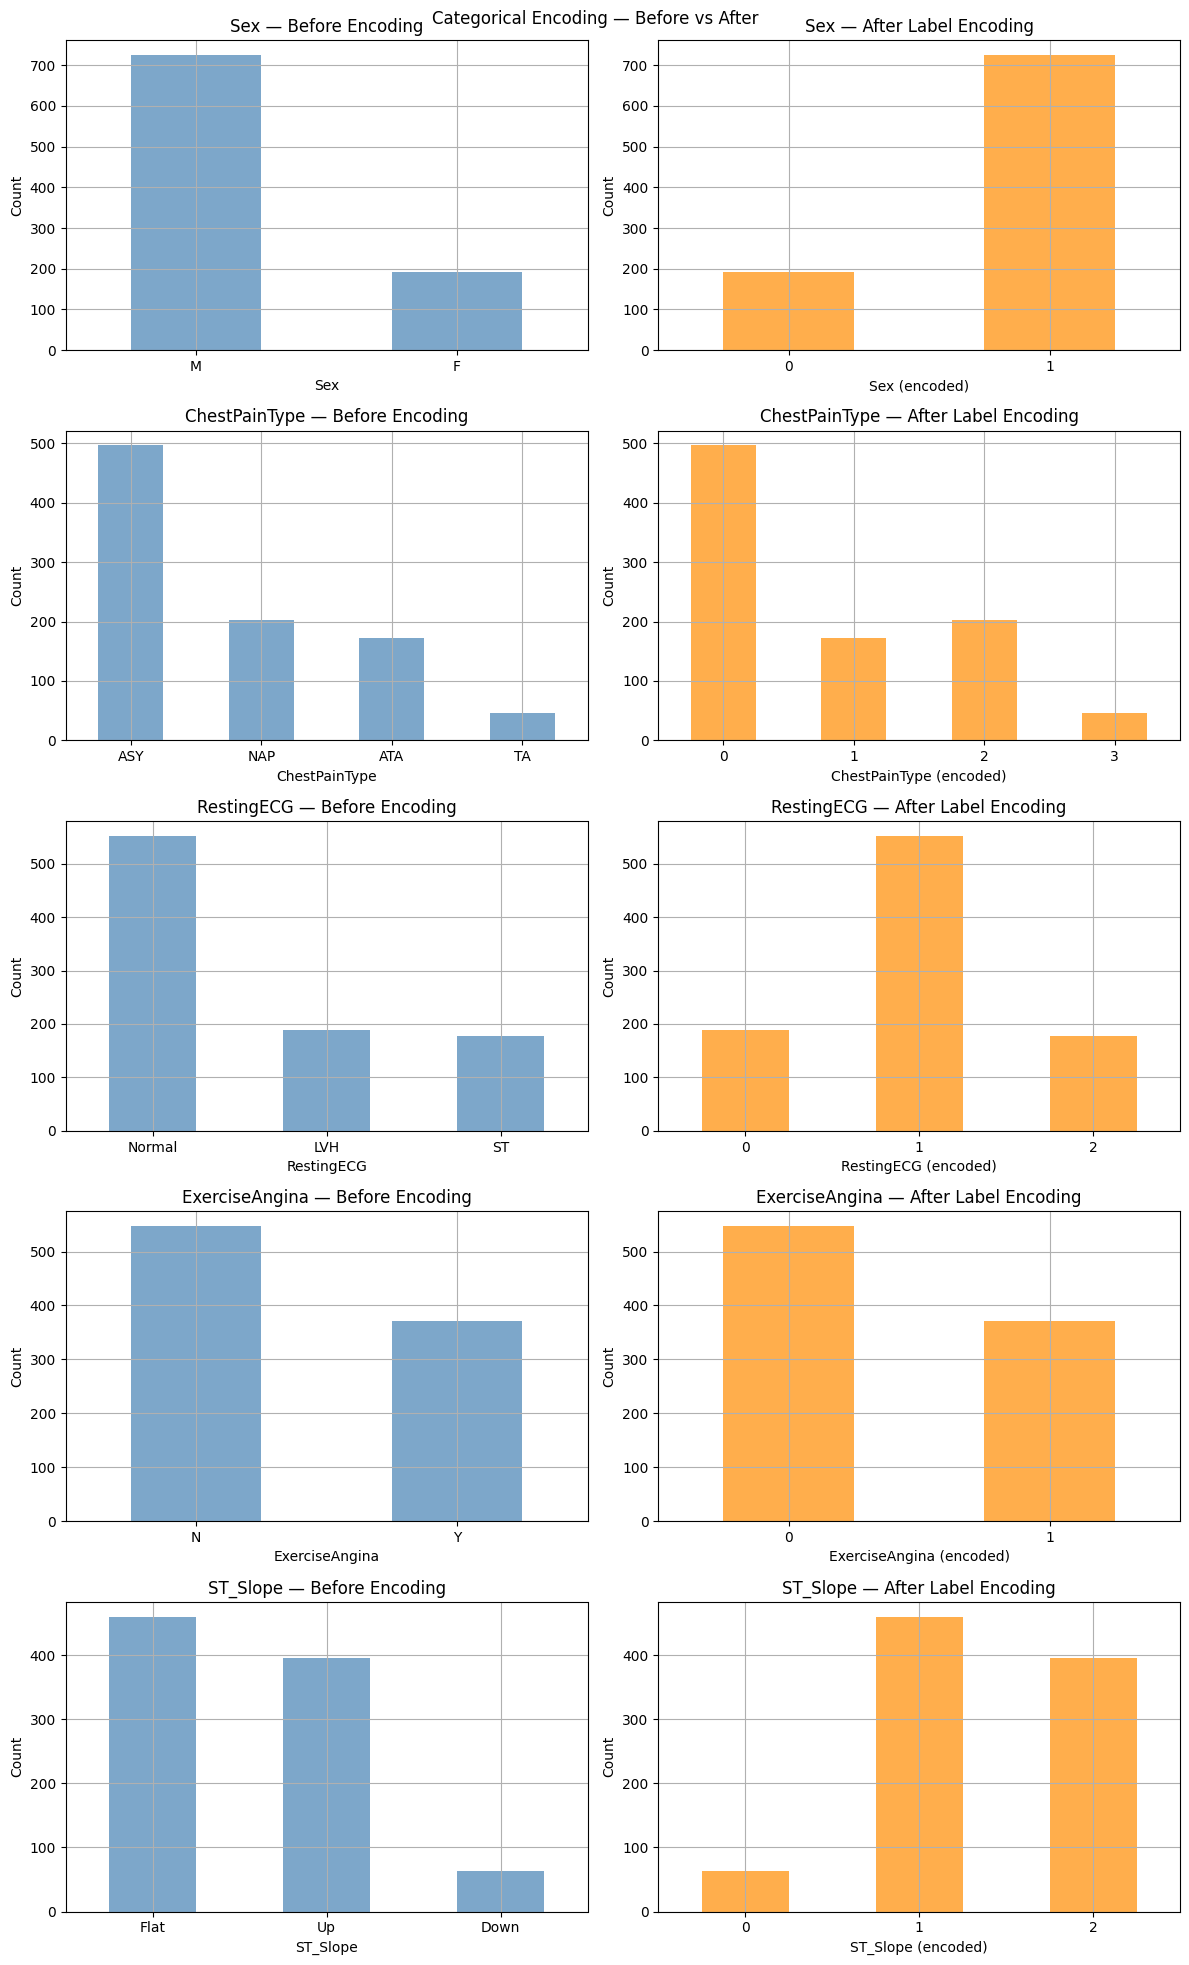

In [9]:
# Encoding Visualization

original_df = pd.read_csv(csv_file)
cat_cols_vis = original_df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(nrows=len(cat_cols_vis), ncols=2,
                          figsize=(12, len(cat_cols_vis) * 4))

for i, col in enumerate(cat_cols_vis):
    # Before encoding
    original_df[col].value_counts().plot(
        kind='bar', ax=axes[i, 0],
        color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{col} — Before Encoding')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].grid(True)
    axes[i, 0].tick_params(axis='x', rotation=0)

    # After encoding
    df[col].value_counts().sort_index().plot(
        kind='bar', ax=axes[i, 1],
        color='darkorange', alpha=0.7)
    axes[i, 1].set_title(f'{col} — After Label Encoding')
    axes[i, 1].set_xlabel(f'{col} (encoded)')
    axes[i, 1].set_ylabel('Count')
    axes[i, 1].grid(True)
    axes[i, 1].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Encoding — Before vs After', fontsize=12)
plt.tight_layout()
plt.show()

## **Define Features & Targets**

**Separate target y and features X first before any scaling
to clear separation before touching the data.**

In [10]:
# Define Target & Features 

y = df['HeartDisease']
X = df.drop(columns=['HeartDisease'])

**Then scalling X and y after they are defined.**

## **Scaling The Features** 

In [11]:
#  Scale All Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"All features scaled: {X_scaled.shape}")

All features scaled: (918, 11)


**Show side by side comparison of feature distributions before and after StandardScaler to visualize preprocessing impact on data.**

Numerical columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


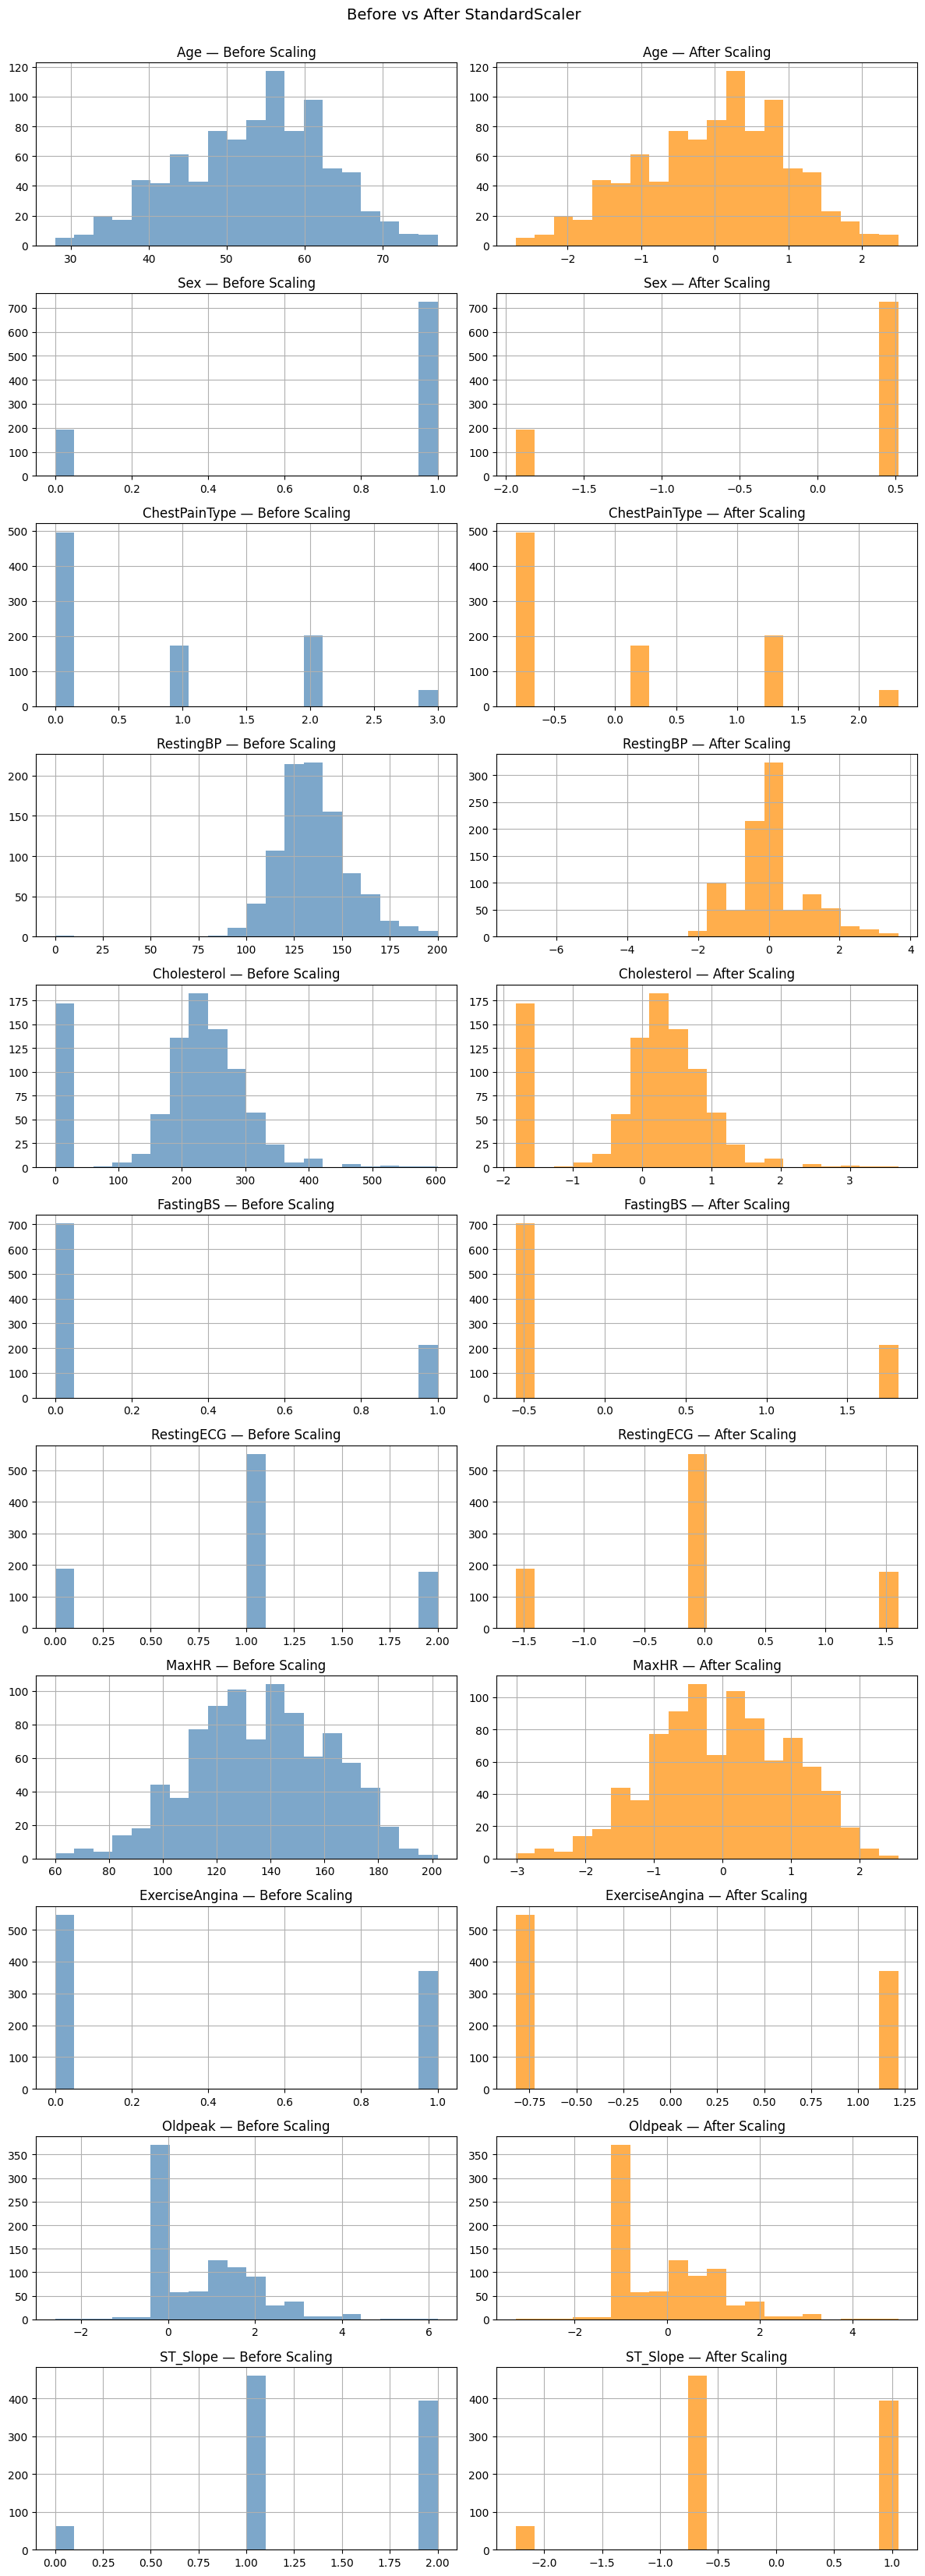

In [12]:
#  Before/After Normalization

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [col for col in num_cols if col not in ['HeartDisease', 'Cluster']]

print(f"Numerical columns: {num_cols}")


fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, 
                          figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    col_idx = list(X.columns).index(col)
    
    # Before
    axes[i, 0].hist(X[col], bins=20, color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{col} — Before Scaling')
    axes[i, 0].grid(True)

    # After
    axes[i, 1].hist(X_scaled[:, col_idx], bins=20, color='darkorange', alpha=0.7)
    axes[i, 1].set_title(f'{col} — After Scaling')
    axes[i, 1].grid(True)

plt.suptitle('Before vs After StandardScaler', fontsize=14 , y=1)
plt.tight_layout()
plt.show()

## *Explanatory Data Analysis (EDA)*

**Show some EDA visualizations for all numerical features to understand feature distributions and how they relate to each other.**

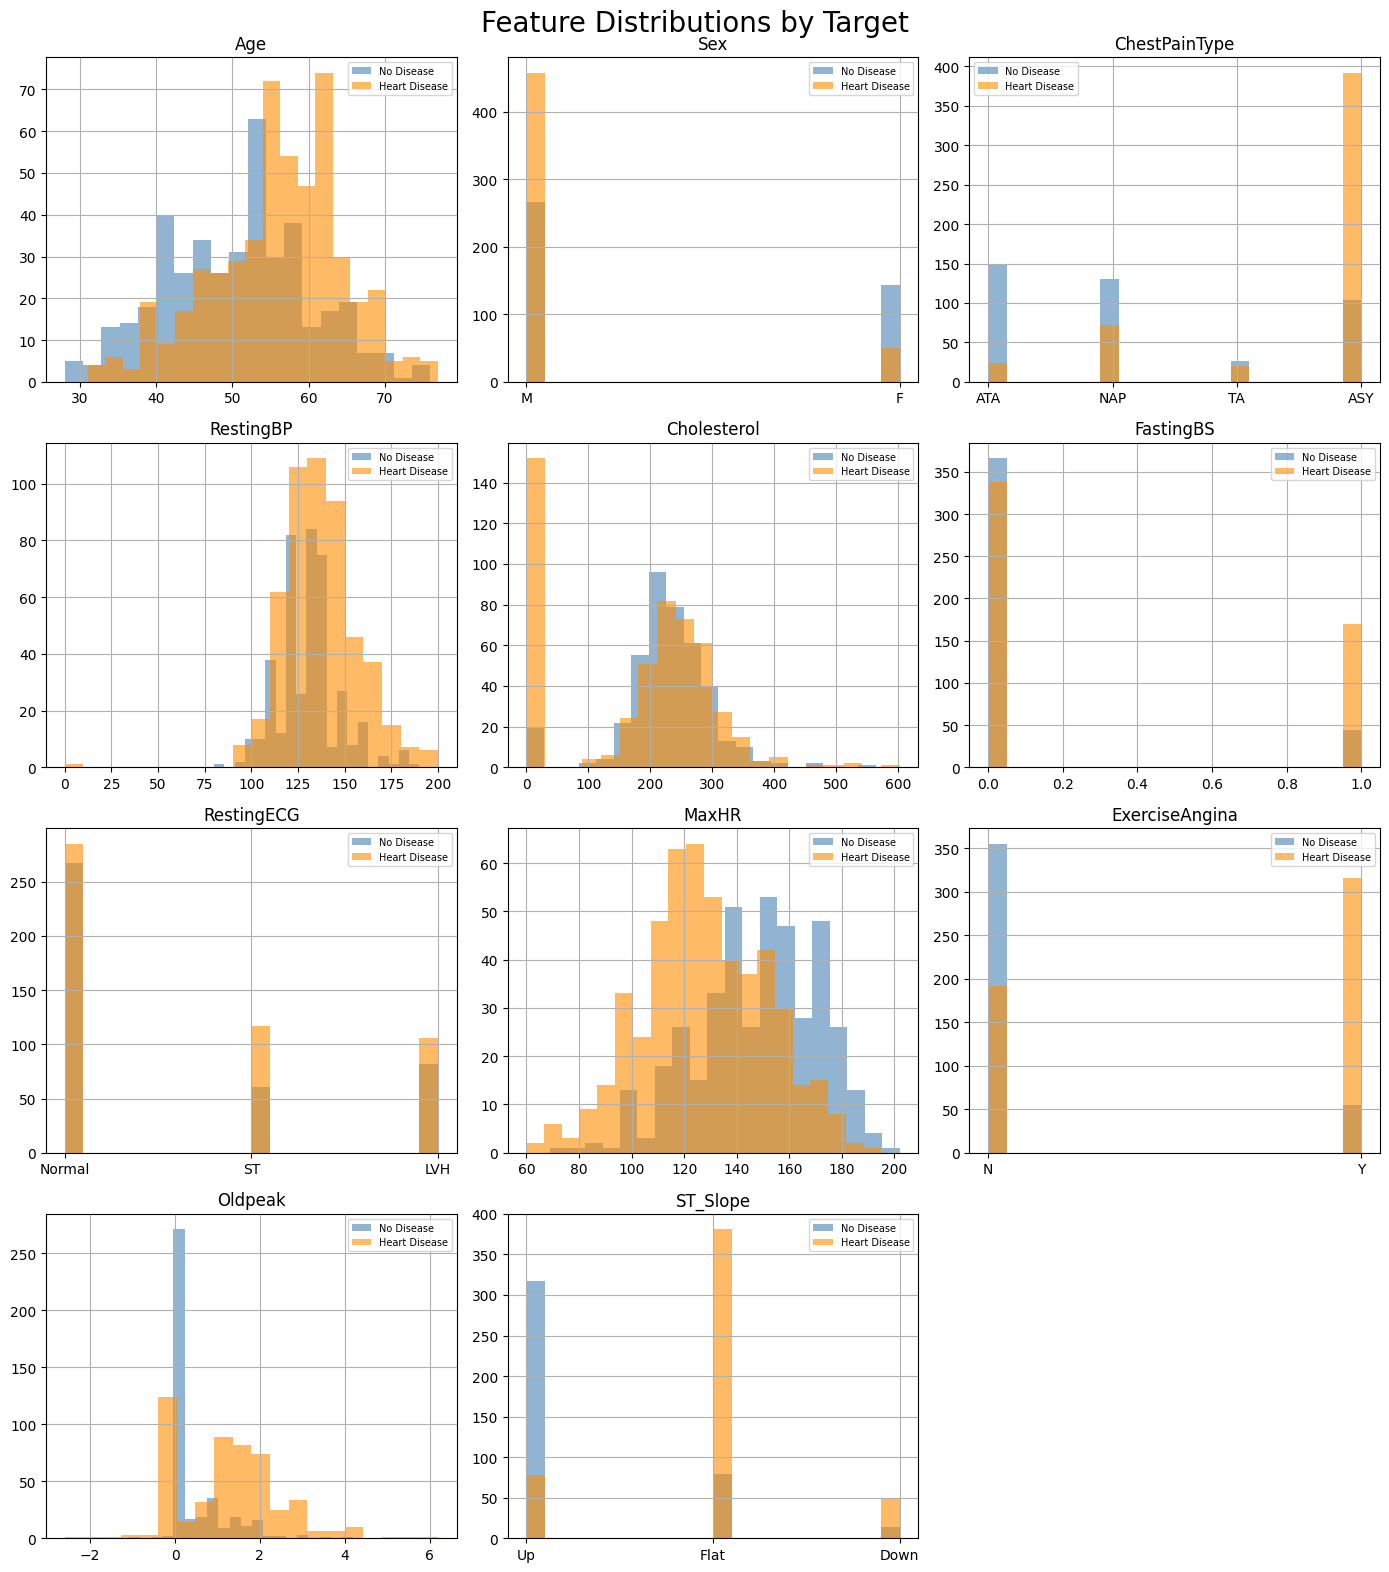

In [13]:
# Distribution Plots

df_orig = pd.read_csv(csv_file)
all_cols = [col for col in df_orig.columns if col != 'HeartDisease']

n_cols = 3
n_rows = int(np.ceil(len(all_cols) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    if df_orig[col].dtype == 'object':
        # Categorical — grouped bar chart
        counts = df_orig.groupby([col, 'HeartDisease']).size().unstack(fill_value=0)
        counts.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'],
                    alpha=0.6, legend=False)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
    else:
        # Numerical — overlapping histograms
        ax.hist(df_orig[df_orig['HeartDisease']==0][col], alpha=0.6,
                color='steelblue', label='No Disease', bins=20)
        ax.hist(df_orig[df_orig['HeartDisease']==1][col], alpha=0.6,
                color='darkorange', label='Heart Disease', bins=20)
    ax.set_title(col)
    ax.legend(['No Disease', 'Heart Disease'], fontsize=7)
    ax.grid(True)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Target', fontsize=20)
plt.tight_layout()
plt.show()


**Show box plots for numerical features by target to spot outliers and compare spread between classes.**

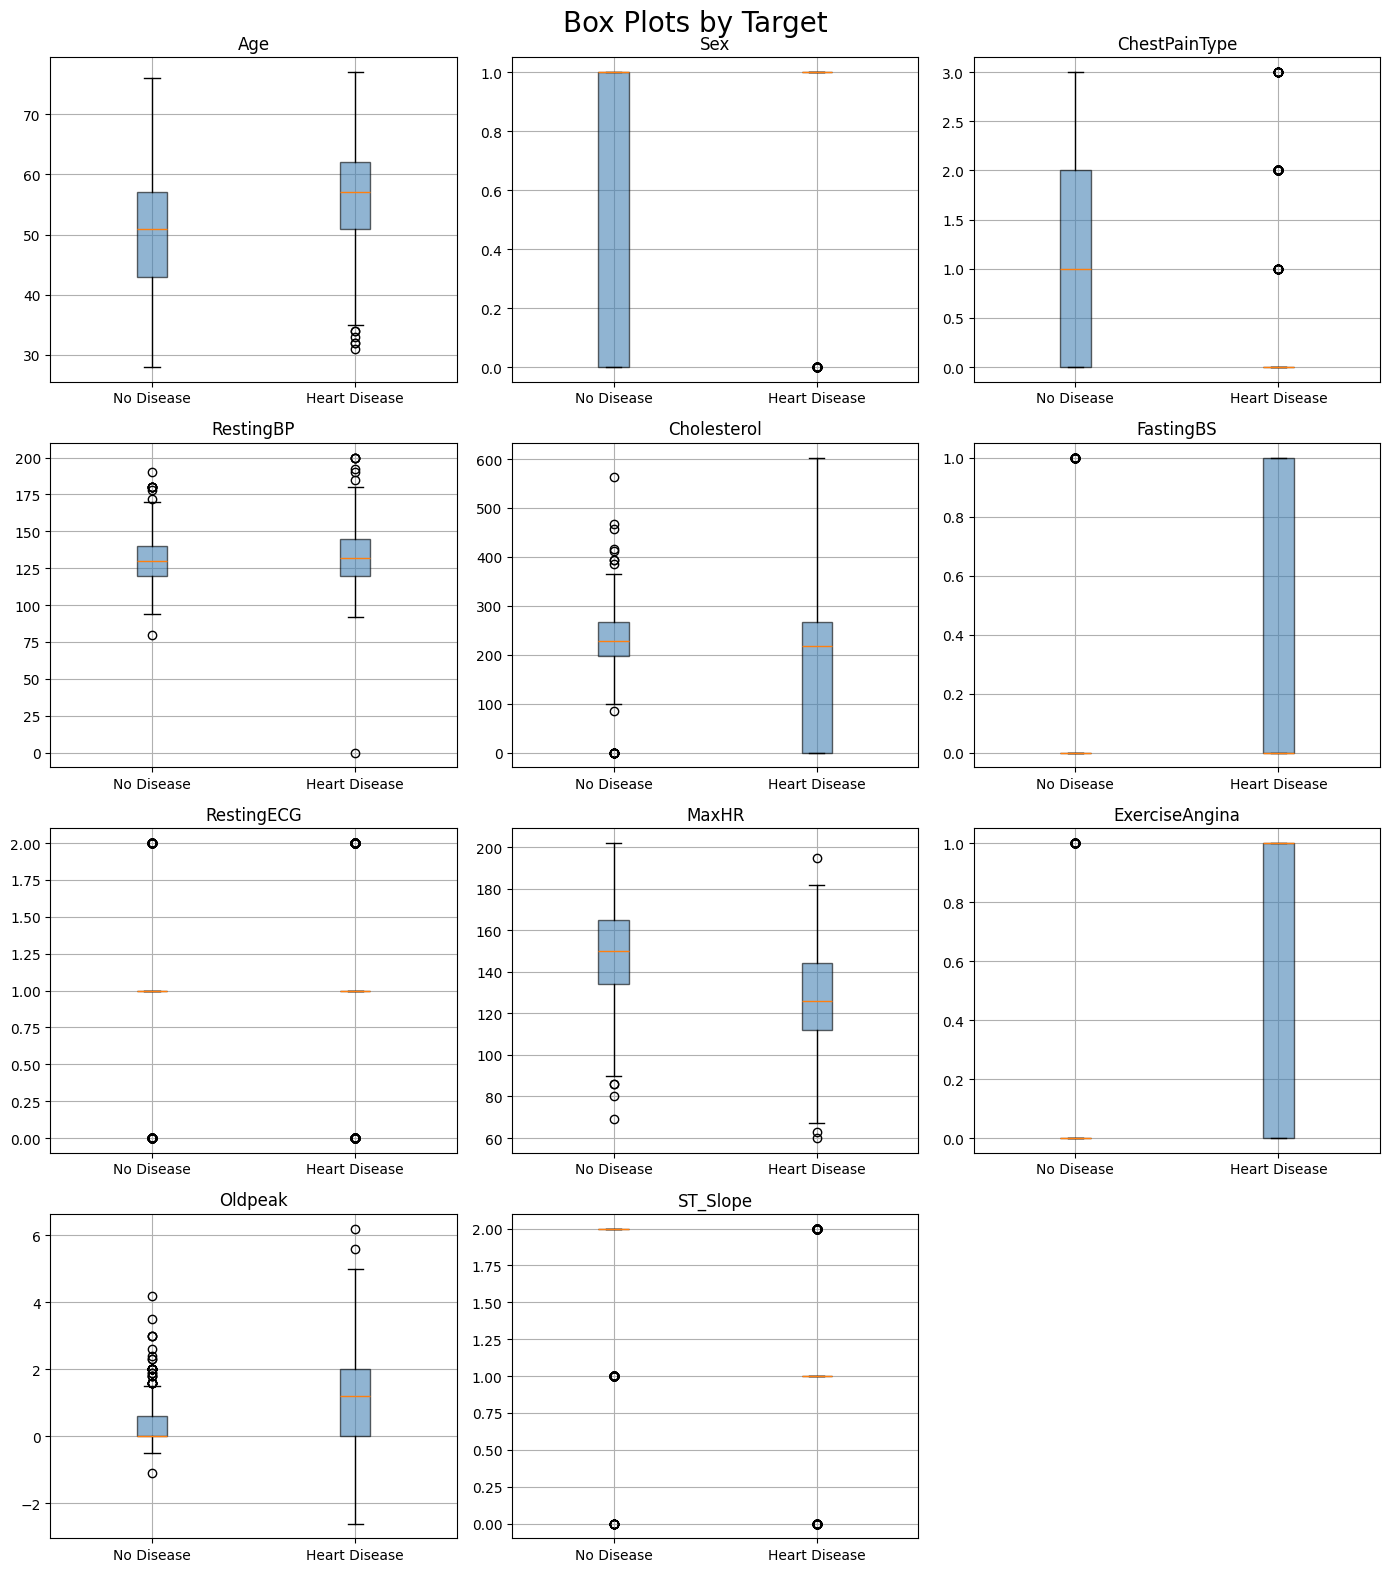

In [14]:
# Box Plots

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_0 = df[df['HeartDisease']==0][col]
    data_1 = df[df['HeartDisease']==1][col]
    axes[i].boxplot([data_0, data_1],
                    labels=['No Disease', 'Heart Disease'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    axes[i].grid(True)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots by Target', fontsize=20)
plt.tight_layout()
plt.show()

**Show IQR-based outlier detection and visualization to identify and quantify outliers per feature.**

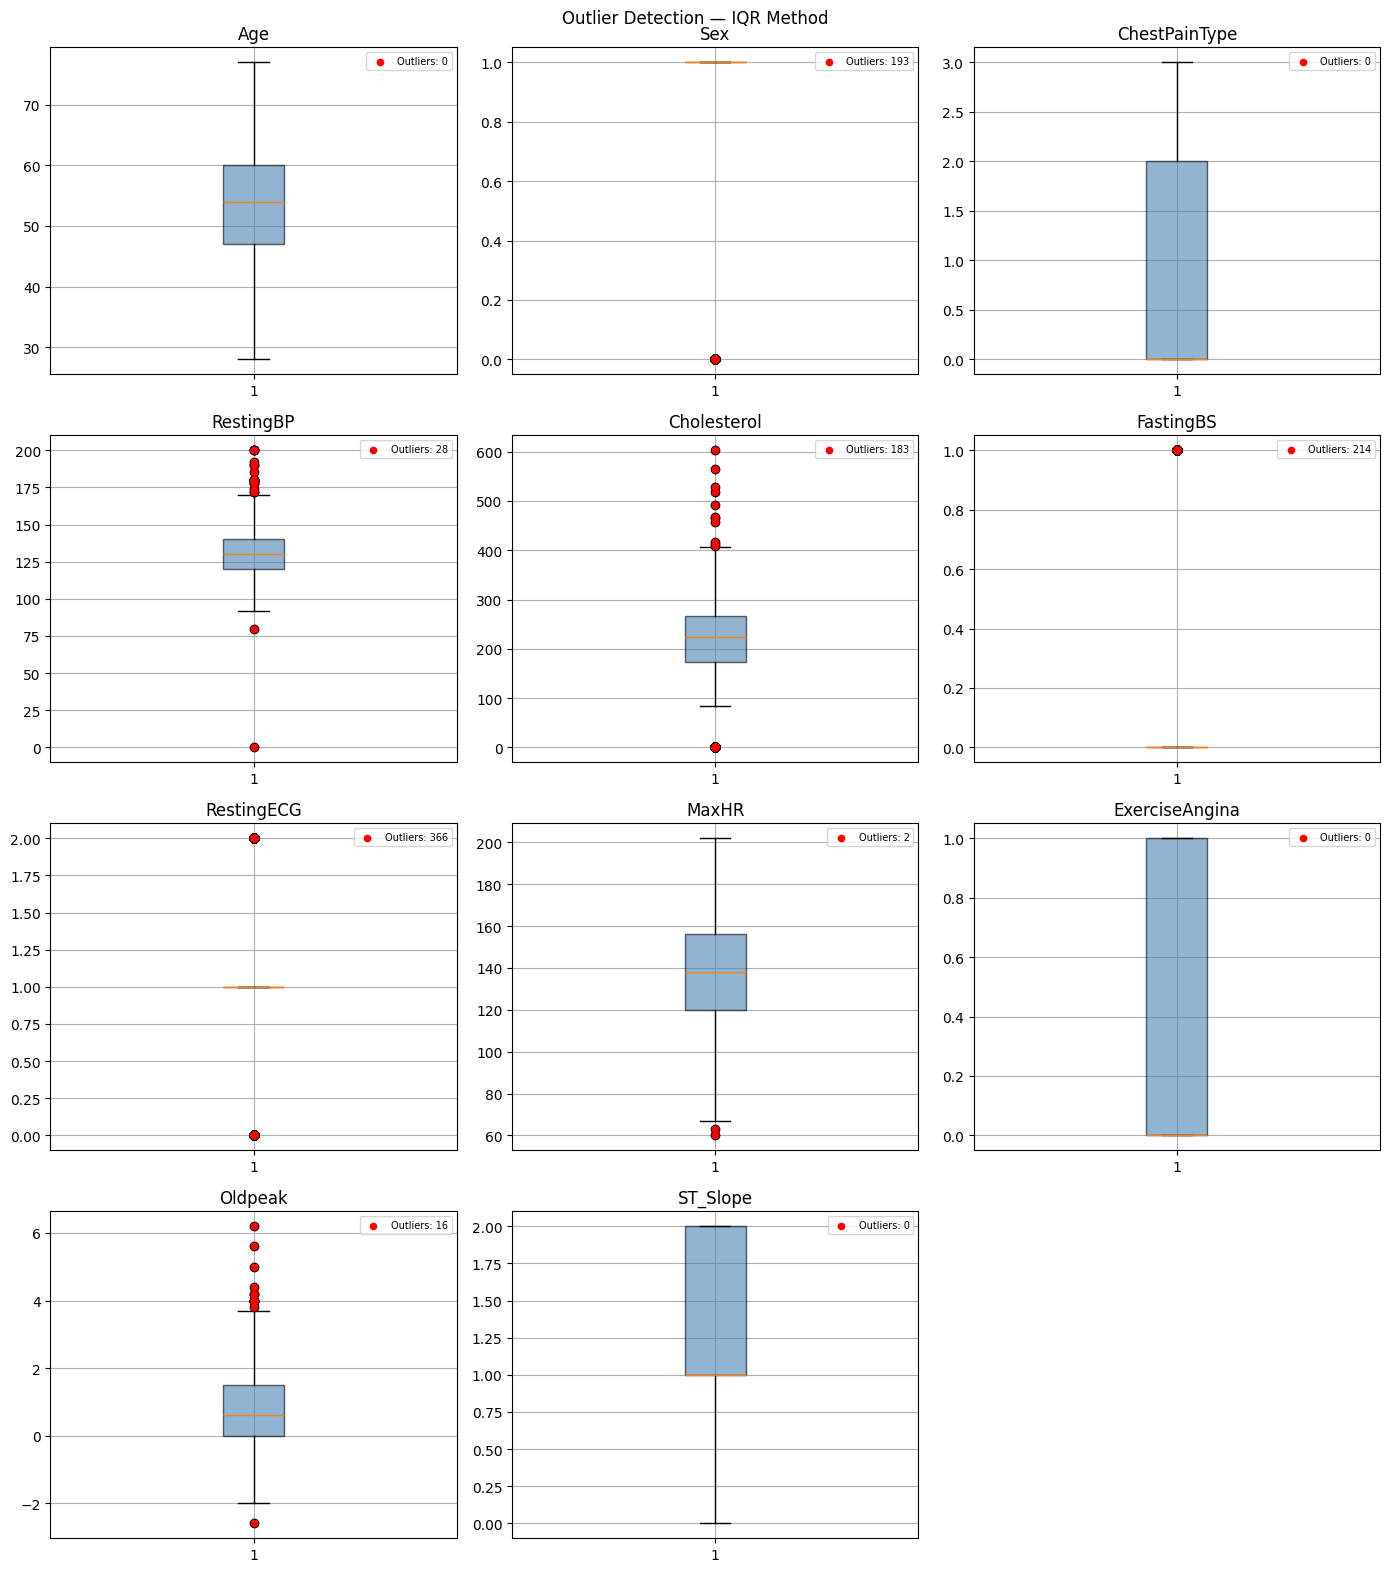


Outlier counts per feature:
  Age: 0 outliers (0.0%)
  Sex: 193 outliers (21.0%)
  ChestPainType: 0 outliers (0.0%)
  RestingBP: 28 outliers (3.1%)
  Cholesterol: 183 outliers (19.9%)
  FastingBS: 214 outliers (23.3%)
  RestingECG: 366 outliers (39.9%)
  MaxHR: 2 outliers (0.2%)
  ExerciseAngina: 0 outliers (0.0%)
  Oldpeak: 16 outliers (1.7%)
  ST_Slope: 0 outliers (0.0%)


In [15]:
# Outlier Detection

outlier_summary = {}

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].scatter([1] * len(outliers),
                    outliers[col],
                    color='red', zorder=5, s=20,
                    label=f'Outliers: {len(outliers)}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
    axes[i].grid(True)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — IQR Method', fontsize=12)
plt.tight_layout()
plt.show()

print("\nOutlier counts per feature:")
for col, count in outlier_summary.items():
    print(f"  {col}: {count} outliers ({count/len(df)*100:.1f}%)")

**Show Correlation Matrix Heatmap of correlations between all numerical features to identify relationships and multicollinearity.**

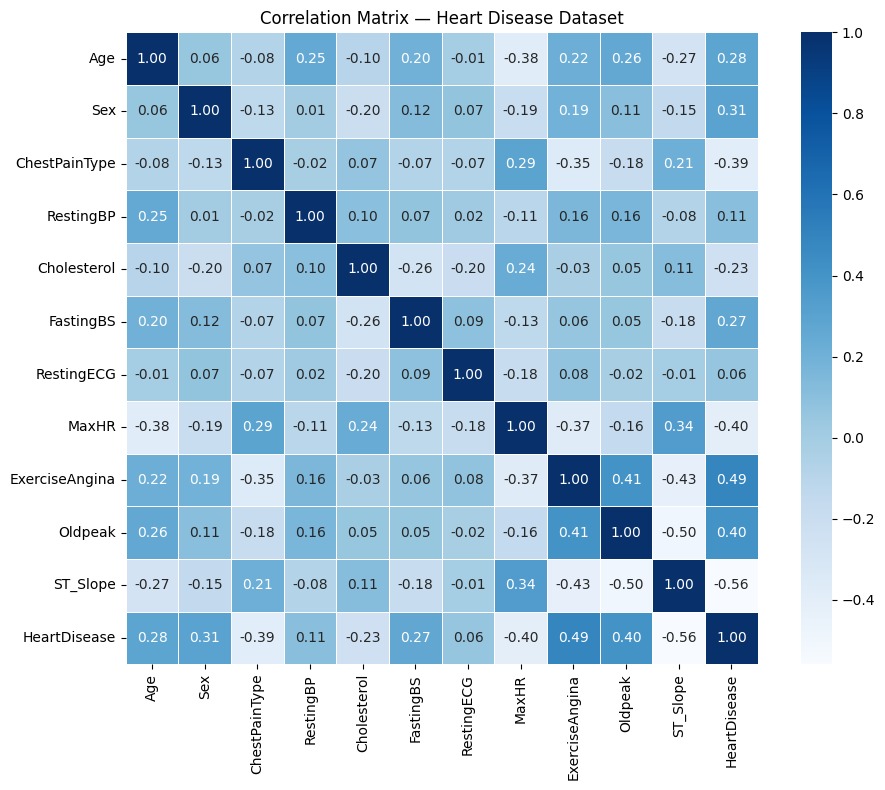

In [16]:
# Correlation Matrix

corr = df[num_cols + ['HeartDisease']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Heart Disease Dataset')
plt.tight_layout()
plt.show()

**Show scatter plots of key feature pairs colored by target to visualize relationships between features and target.**

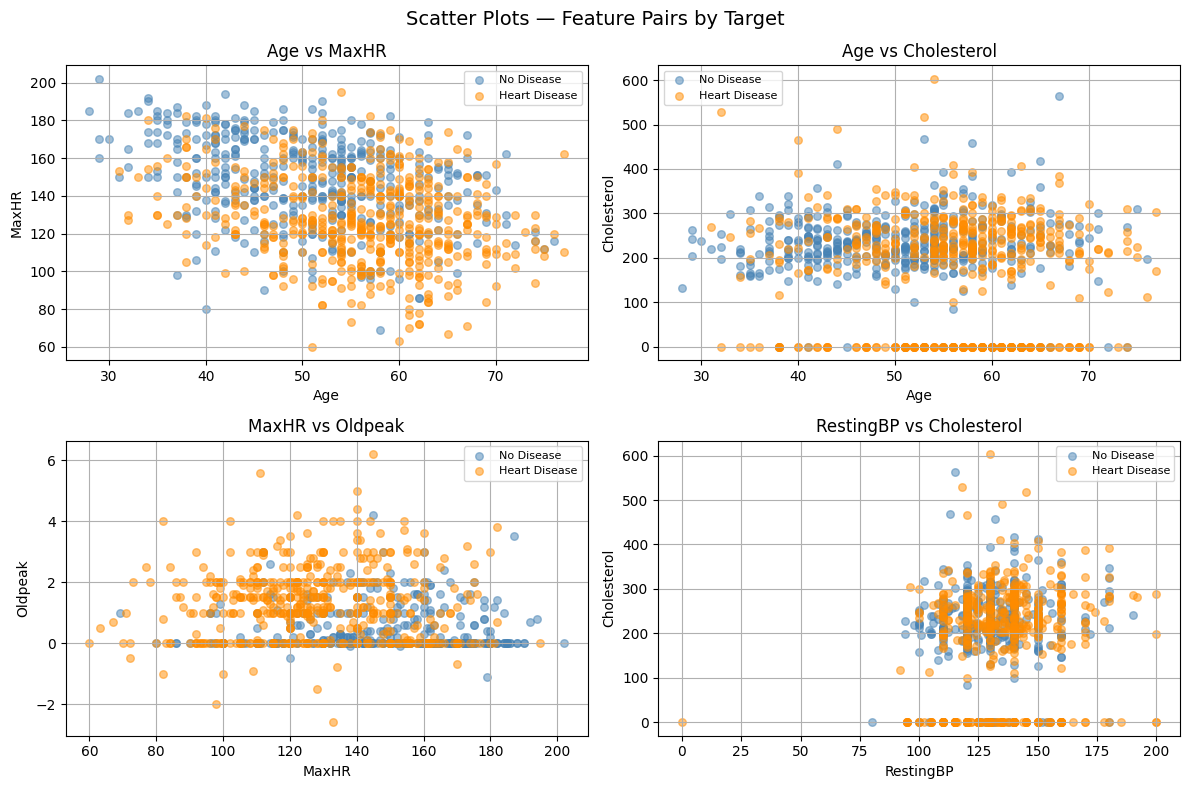

In [17]:
# Scatter Plots

scatter_pairs = [
    ('Age', 'MaxHR'),
    ('Age', 'Cholesterol'),
    ('MaxHR', 'Oldpeak'),
    ('RestingBP', 'Cholesterol'),
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

colors = {0: 'steelblue', 1: 'darkorange'}
labels = {0: 'No Disease', 1: 'Heart Disease'}

for i, (x_col, y_col) in enumerate(scatter_pairs):
    for cls in [0, 1]:
        subset = df[df['HeartDisease'] == cls]
        axes[i].scatter(subset[x_col], subset[y_col],
                        alpha=0.5, s=30,
                        color=colors[cls],
                        label=labels[cls])
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f'{x_col} vs {y_col}')
    axes[i].legend(fontsize=8)
    axes[i].grid(True)

plt.suptitle('Scatter Plots — Feature Pairs by Target', fontsize=14)
plt.tight_layout()
plt.show()

## **Splitting the Data To Training and Test Sets**

**Now split the data into training and testing sets to evaluate model on unseen data.**

In [18]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nX_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Target balance (train): {pd.Series(y_train).value_counts().to_dict()}")


X_train: (734, 11)
X_test : (184, 11)
Target balance (train): {1: 406, 0: 328}


# **Model Training**

**Train Random Forest classifier on Medical Condition as per experience it is the best performing model for tabular data and it is also the most interpretable one with SHAP values.**

In [19]:
# Train Random Forest Model

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"\nAccuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision : {precision_score(y_test, y_pred):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


Accuracy  : 0.875
Precision : 0.883
Recall    : 0.892
F1-Score  : 0.888

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



## **Visualizations to show model performance**

**Plot confusion matrix to visual evaluation of classification performance.**

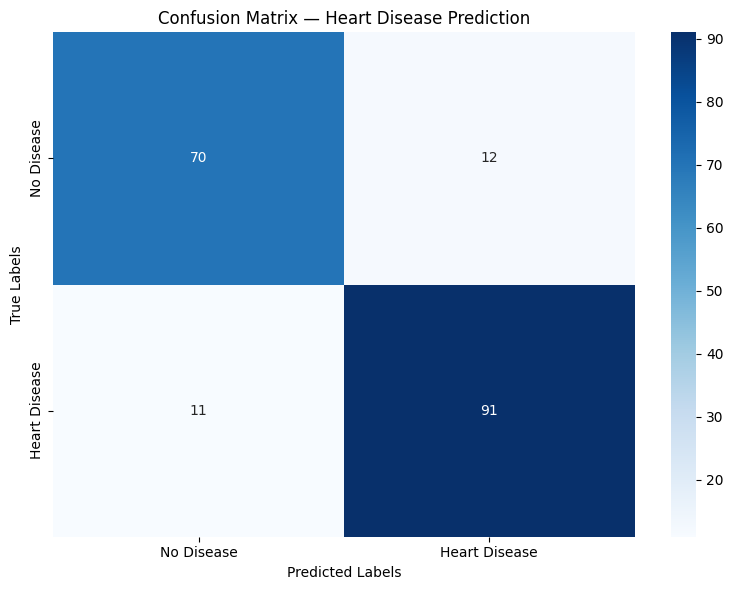

In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix — Heart Disease Prediction')
plt.tight_layout()
plt.show()

**Plot ROC curve with AUC score to evaluate model discrimination ability.**

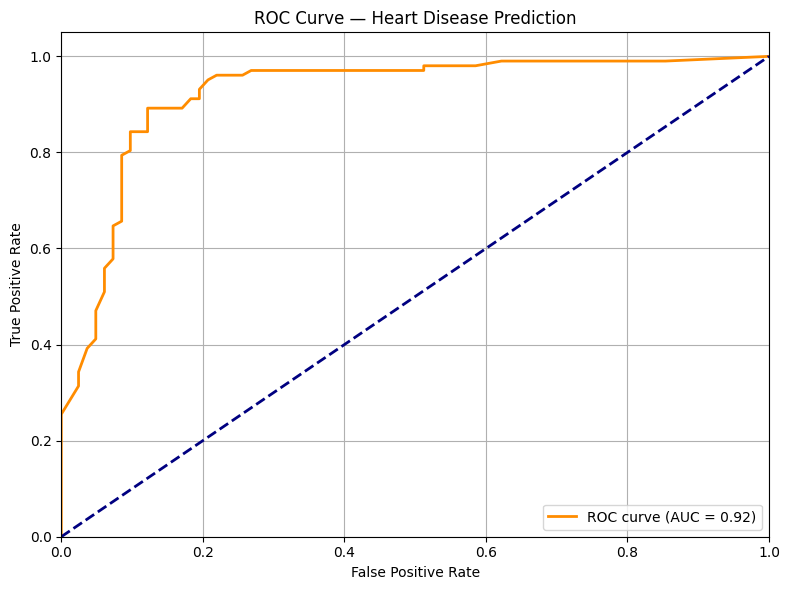

In [21]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Heart Disease Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

**Plot Precision-Recall curve with AUC score because it is important for evaluating imbalanced classification as well as evaluating model performance beyond ROC.**

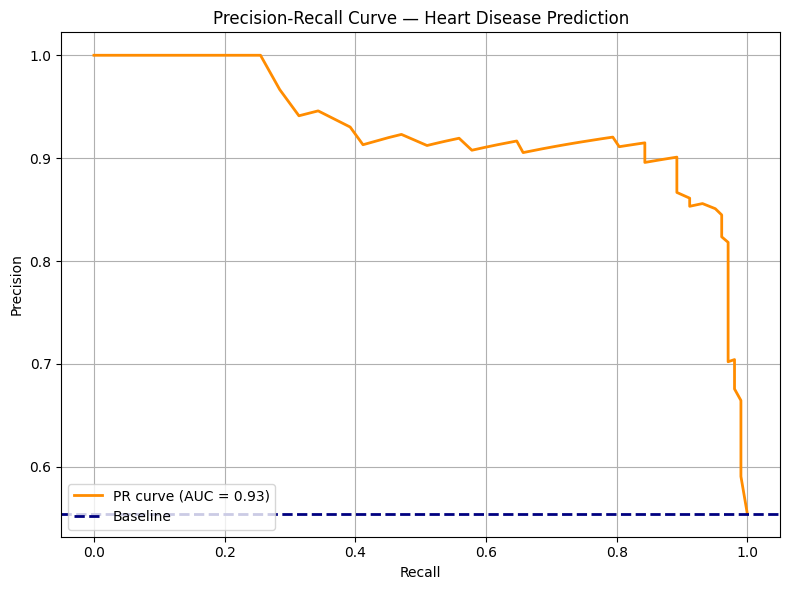

In [22]:
# Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'PR curve (AUC = {pr_auc:.2f})')
plt.axhline(y=y_test.mean(), color='navy', lw=2,
            linestyle='--', label='Baseline')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Heart Disease Prediction')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

**Show Q-Q plot of predicted probabilities vs normal distribution to check if predicted probabilities follow a normal distribution**

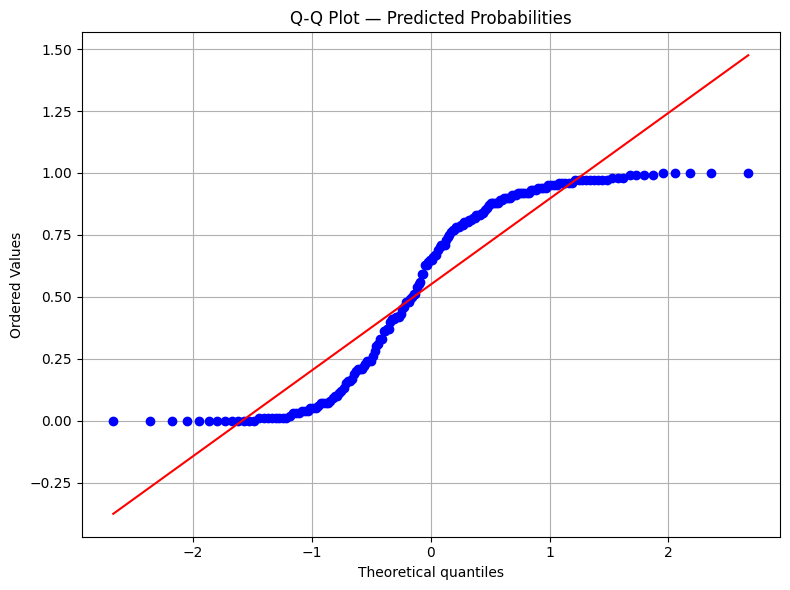

In [23]:
# Q-Q Plot

plt.figure(figsize=(8, 6))
stats.probplot(y_proba, dist='norm', plot=plt)
plt.title('Q-Q Plot — Predicted Probabilities')
plt.grid(True)
plt.tight_layout()
plt.show()

**Plot residuals (actual - predicted probability) to check prediction errors distribution.**



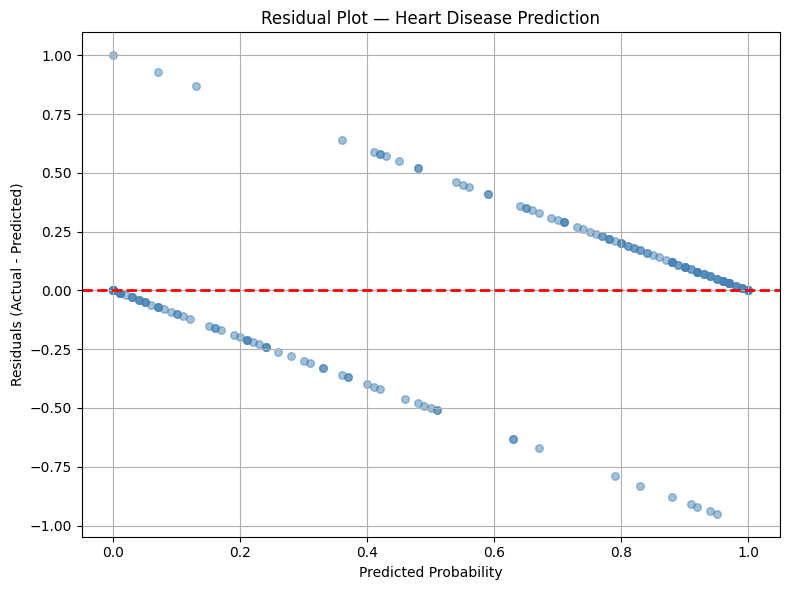

In [24]:
# Residual Plot

residuals = y_test.values - y_proba

plt.figure(figsize=(8, 6))
plt.scatter(y_proba, residuals,
            alpha=0.5, color='steelblue', s=30)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Probability')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot — Heart Disease Prediction')
plt.grid(True)
plt.tight_layout()
plt.show()

**Plot predicted probabilities vs actual labels to visualize how well predictions align with actual outcomes.**

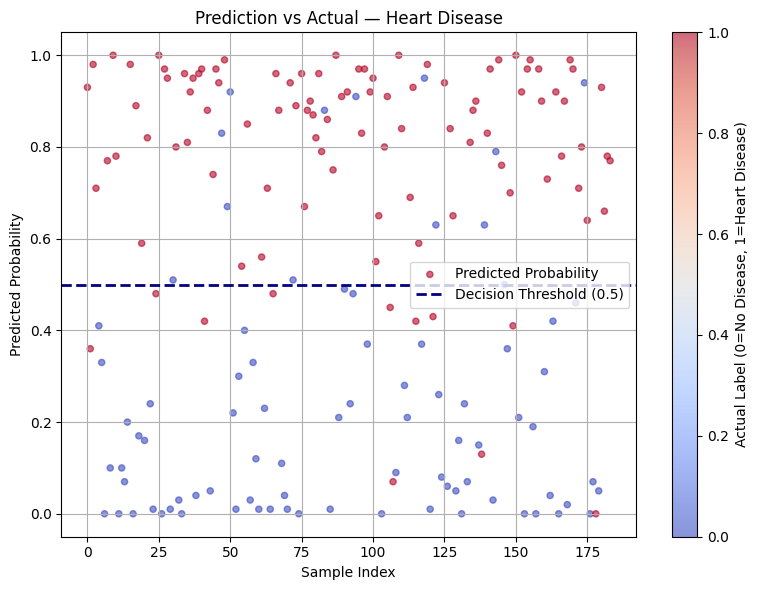

In [25]:
# Prediction vs Actual

plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_test)), y_proba,
            c=y_test.values, cmap='coolwarm',
            alpha=0.6, s=20, label='Predicted Probability')
plt.axhline(y=0.5, color='navy', linestyle='--',
            lw=2, label='Decision Threshold (0.5)')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Probability')
plt.title('Prediction vs Actual — Heart Disease')
plt.colorbar(label='Actual Label (0=No Disease, 1=Heart Disease)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Plot top feature importances from the model to understand which features drive predictions the most.**

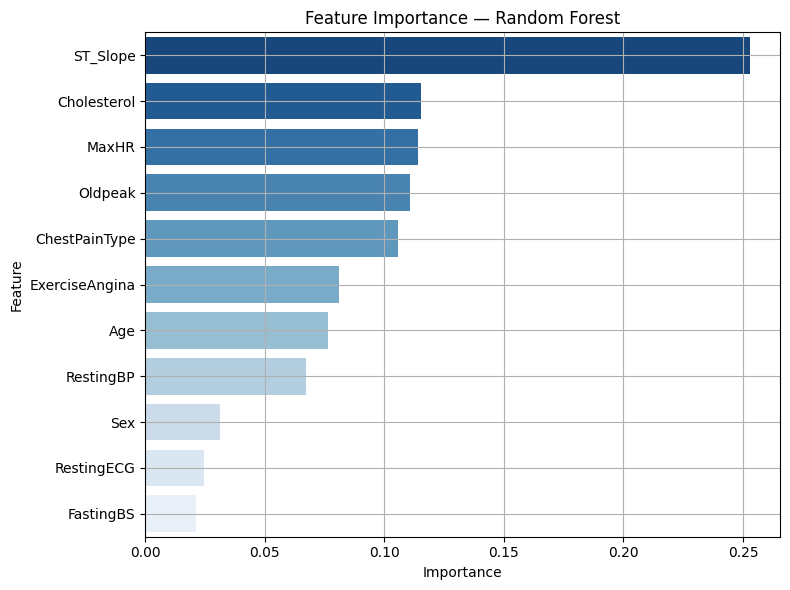


       Feature  Importance
      ST_Slope    0.252837
   Cholesterol    0.115252
         MaxHR    0.113833
       Oldpeak    0.110641
 ChestPainType    0.105808
ExerciseAngina    0.080912
           Age    0.076545
     RestingBP    0.067069
           Sex    0.031110
    RestingECG    0.024690
     FastingBS    0.021302


In [26]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance,
            palette='Blues_r')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\n{feature_importance.to_string(index=False)}")

**Make pair plot of all numerical features colored by target to see all feature relationships at once in one grid.**

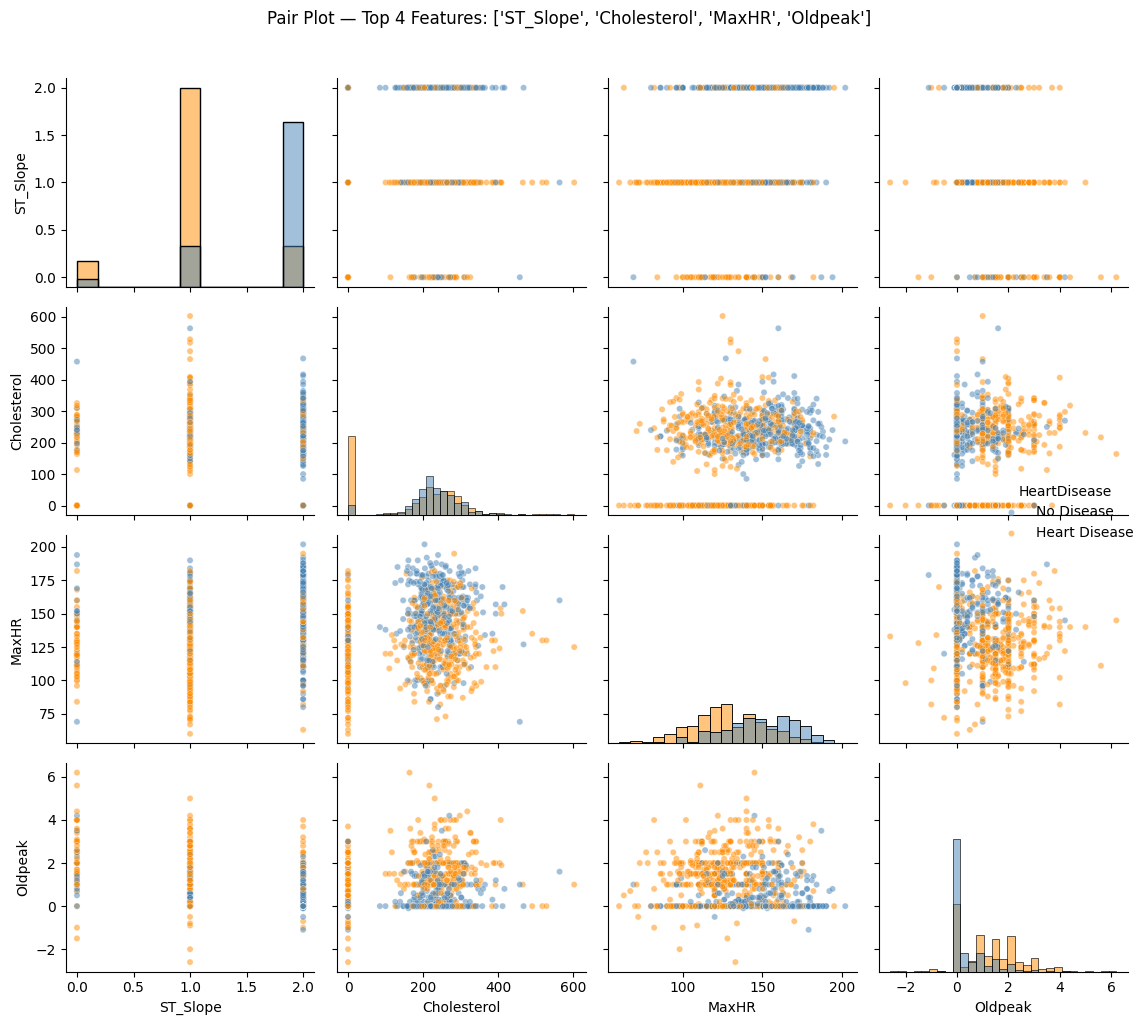

In [27]:
# Pair Plot (Top Features Only)

top_features = feature_importance['Feature'].head(4).tolist()

pair_df = df[top_features + ['HeartDisease']].copy()
pair_df['HeartDisease'] = pair_df['HeartDisease'].map({0: 'No Disease',
                                                        1: 'Heart Disease'})

sns.pairplot(pair_df, hue='HeartDisease',
             palette={'No Disease'   : 'steelblue',
                      'Heart Disease': 'darkorange'},
             plot_kws={'alpha': 0.5, 's': 20},
             diag_kind='hist')

plt.suptitle(f'Pair Plot — Top 4 Features: {top_features}', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# **Clustring (KMeans , PCA and t-SNE)**

## KMeans

**Start with Elbow plot to find optimal K, then fit KMeans.**

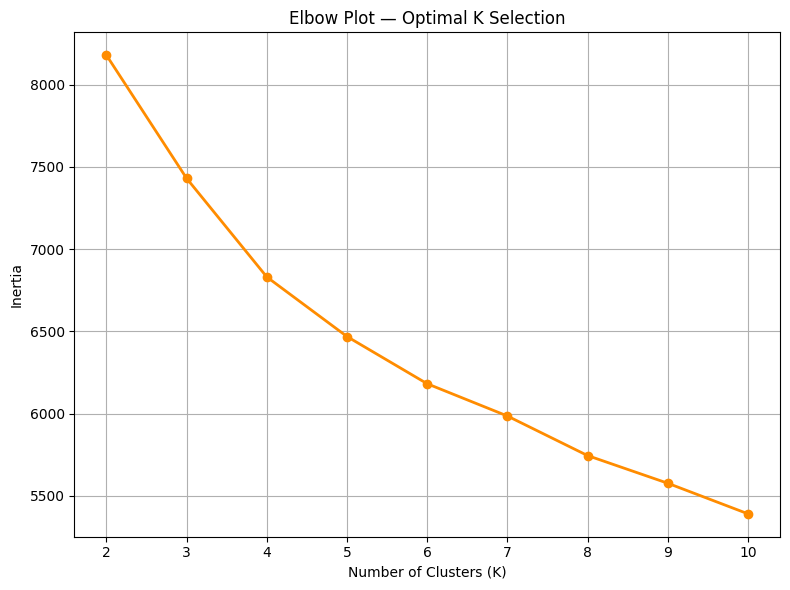

In [28]:
# Elbow Plot

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o', color='darkorange', lw=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Plot — Optimal K Selection')
plt.grid(True)
plt.tight_layout()
plt.show()

**Fit KMeans with K=4 as the elbow plot shows that after 4 the inertia difference becomes less significant, indicating that 4 clusters may be a good choice for segmenting the patients into natural groups based on their features.**

In [29]:
# Fit KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

print(f"KMeans fitted with K=4")
print(f"\nCluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

KMeans fitted with K=4

Cluster distribution:
0    183
1    282
2    156
3    297
Name: count, dtype: int64


# **PCA Cluster Visualization**
**Reduce the data to 2D with PCA to reduce the data dimensionality for better visualization of the clusters in 2D space as PCA helps to capture the most important variance in the data while projecting it onto two principal components.**

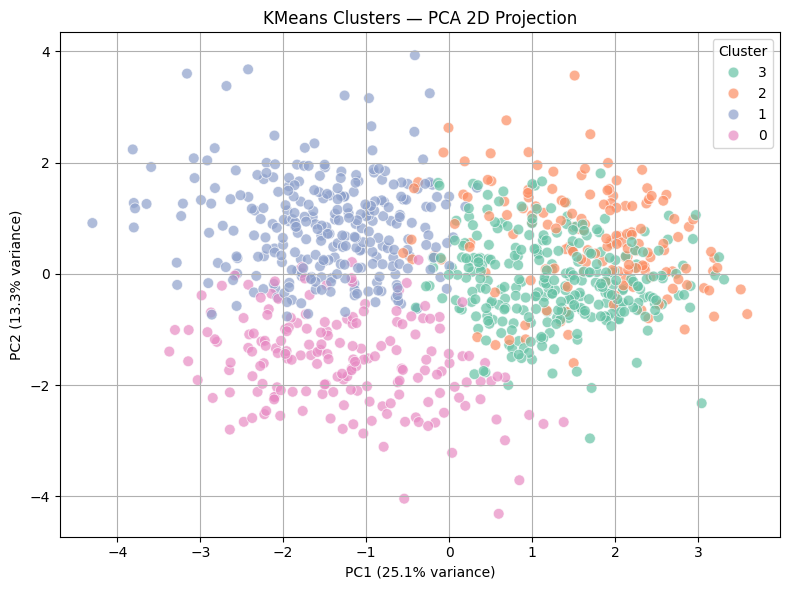

Explained variance: 38.4%


In [30]:
# PCA Cluster Visualization

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1'    : X_pca[:, 0],
    'PC2'    : X_pca[:, 1],
    'Cluster': cluster_labels.astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                hue='Cluster', palette='Set2',
                alpha=0.7, s=60)
plt.title('KMeans Clusters — PCA 2D Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# **t-SNE Cluster Visualization (replacing PCA)**
**As PCA with 2 components covers low varaince of data , t-SNE is implemnted to reduce the data to 2D as well and plot clusters. Because it has a better separation than PCA for non-linear structures.**

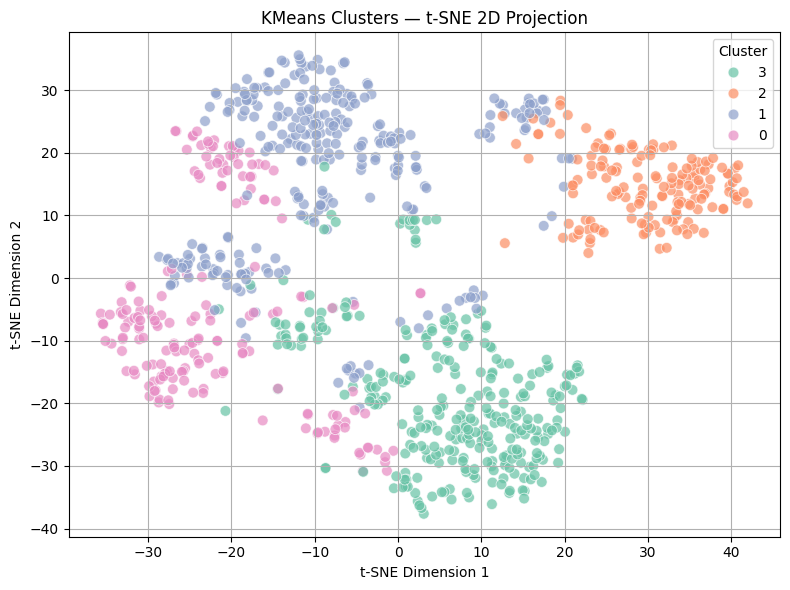

In [31]:
# t-SNE Cluster Visualization

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    'Dim1'   : X_tsne[:, 0],
    'Dim2'   : X_tsne[:, 1],
    'Cluster': cluster_labels.astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2',
                hue='Cluster', palette='Set2',
                alpha=0.7, s=60)
plt.title('KMeans Clusters — t-SNE 2D Projection')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.tight_layout()
plt.show()

**Also try PCA 3D Cluster Visualization with 3 components to cover more variance of data.** 

In [32]:
# PCA 3D Cluster Visualization

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1'    : X_pca[:, 0],
    'PC2'    : X_pca[:, 1],
    'PC3'    : X_pca[:, 2],
    'Cluster': cluster_labels.astype(str)
})

fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                    color='Cluster',
                    color_discrete_sequence=px.colors.qualitative.Set2,
                    title=f'KMeans Clusters — PCA 3D Projection '
                          f'({pca.explained_variance_ratio_.sum()*100:.1f}% variance)',
                    opacity=0.7)

fig.update_layout(plot_bgcolor='white', height=600)
fig.show()

print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"   PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")

Explained variance: 49.0%
   PC1: 25.1%
   PC2: 13.3%
   PC3: 10.5%


**It is observed that when PCA increased the data variance covered increased so the following representation shows the best PCA** 

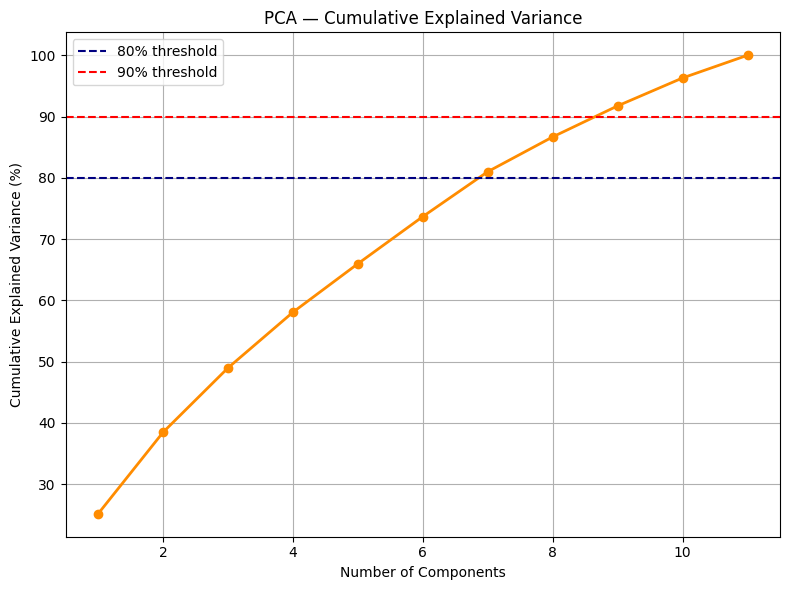

Components needed for 70% variance: 6
Components needed for 80% variance: 7
Components needed for 90% variance: 9


In [33]:
# Check cumulative variance across all components

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance)+1), 
         cumulative_variance, marker='o', color='darkorange', lw=2)
plt.axhline(y=80, color='navy', linestyle='--', label='80% threshold')
plt.axhline(y=90, color='red',  linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print how many components needed
for threshold in [70, 80, 90]:
    n = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Components needed for {threshold}% variance: {n}")

**- 3D PCA (49%) → too low for meaningful visualization**  
**- We need 7+ components for 80% → can't visualize that**   
**- t-SNE is the right call here — it doesn't care about variance, it focuses on preserving local structure and cluster separation**

## **SHAP**

**Showing SHAP values for model interpretability to clarify how each feature contributes to predictions.**

# *SHAP Feature Importance*

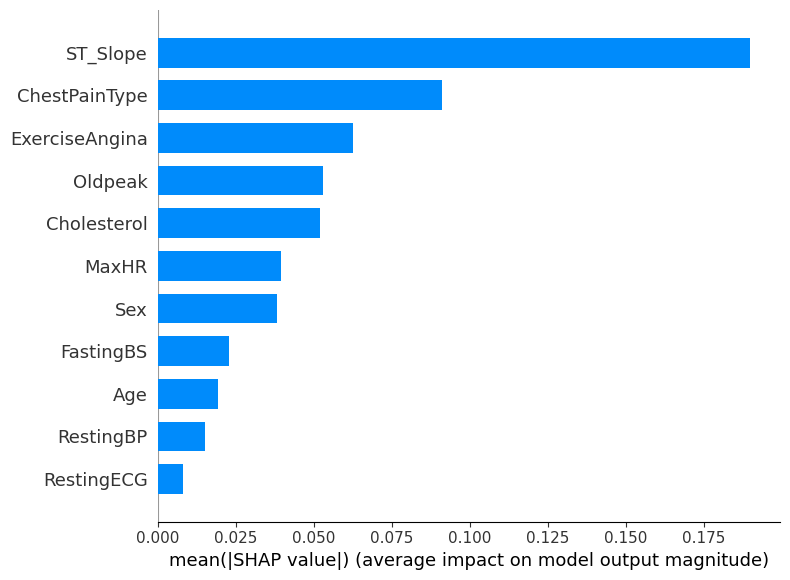

In [34]:
# SHAP Feature Importance

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values[:, :, 1], X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=True)

# *SHAP Summary Plot*

**Show global feature importance via SHAP summary plot as another representation for the features having the most impact on predictions**

sv shape      : (100, 11, 2)
X_sample shape: (100, 11)


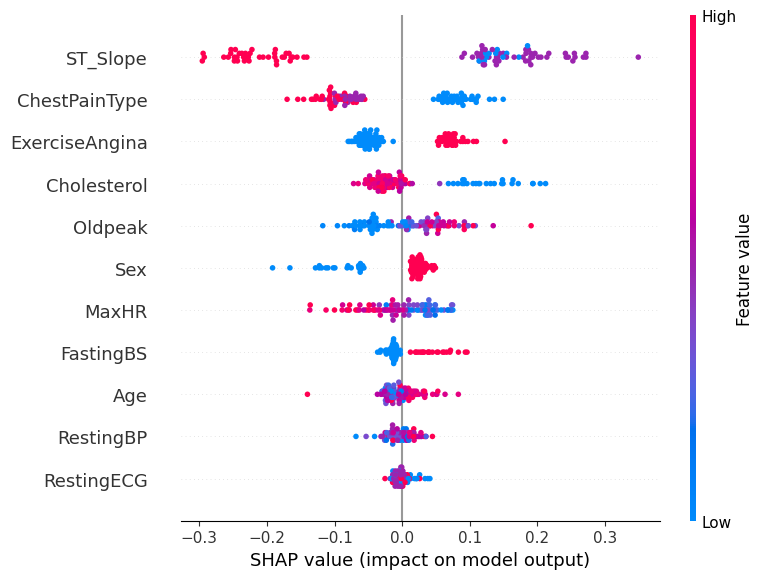

In [35]:
# SHAP Summary Plot

X_sample = pd.DataFrame(X_test[:100], columns=X.columns)
sv       = explainer.shap_values(X_sample)

# Check shape
print(f"sv shape      : {np.array(sv).shape}")
print(f"X_sample shape: {X_sample.shape}")

# If sv is a list (one array per class), take class 1
if isinstance(sv, list):
    sv = sv[1]

shap.summary_plot(sv[:, :, 1], X_sample, 
                  feature_names=X.columns.tolist())

# *SHAP Dependence Plot*

**Slice correctly for class 1 then get top feature as sv[:, :, 1] gives us class 1 SHAP values (100, 11).**

Top feature index: 10
Top feature name : ST_Slope


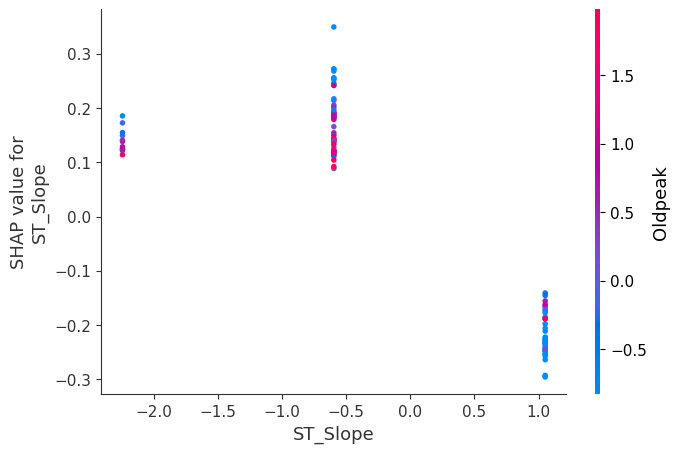

In [36]:
# SHAP Dependence Plot

sv_class1 = sv[:, :, 1]  # shape (100, 11)

top_feature_idx  = int(np.argmax(np.abs(sv_class1).mean(axis=0)))
top_feature_name = X.columns[top_feature_idx]
print(f"Top feature index: {top_feature_idx}")
print(f"Top feature name : {top_feature_name}")

shap.dependence_plot(top_feature_idx, sv_class1, X_sample,
                     feature_names=X.columns.tolist())

# *Decision Boundary (Top 2 SHAP Features)*

**Present the decision boundary plot using top 2 SHAP features to visualize how model separates classes in 2D.**

Top 2 features: ['ChestPainType', 'ST_Slope']


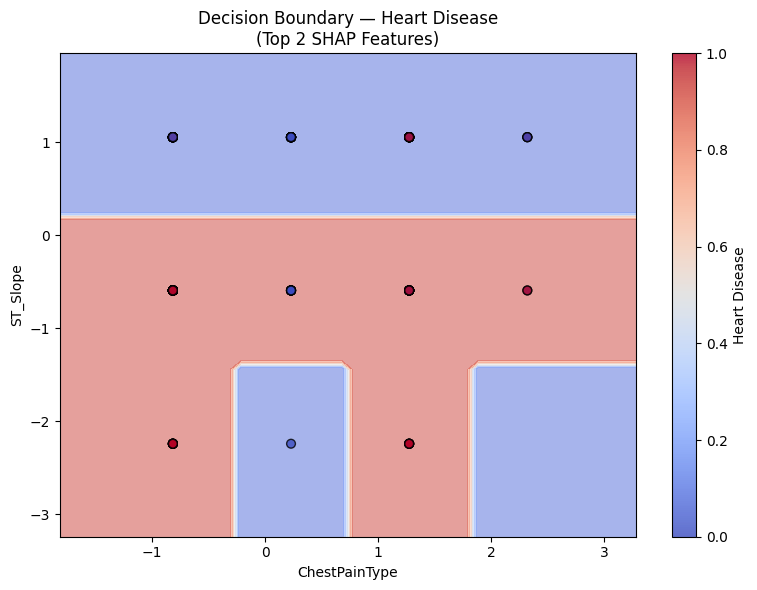

In [37]:
# Decision Boundary — Top 2 SHAP Features

sv_class1 = sv[:, :, 1]

# Top 2 features
top2_indices = np.argsort(np.abs(sv_class1).mean(axis=0))[-2:]
top2_names   = X.columns[top2_indices].tolist()
print(f"Top 2 features: {top2_names}")

# Train RF on top 2 features only
X_train_2d = X_train[:, top2_indices]
X_test_2d  = X_test[:, top2_indices]

rf_2d = RandomForestClassifier(n_estimators=100, random_state=42)
rf_2d.fit(X_train_2d, y_train)

# Mesh grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot — 200 test points only
X_plot = X_test_2d[:200]
y_plot = y_test.values[:200]

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
plt.scatter(X_plot[:, 0], X_plot[:, 1],
            c=y_plot, edgecolors='k', marker='o',
            cmap='coolwarm', alpha=0.8, s=40)
plt.title(f'Decision Boundary — Heart Disease\n(Top 2 SHAP Features)')
plt.xlabel(top2_names[0])
plt.ylabel(top2_names[1])
plt.colorbar(label='Heart Disease')
plt.tight_layout()
plt.show()

## **LIME**

**LIME explanation for a single prediction to explain individual predictions in human-readable form**

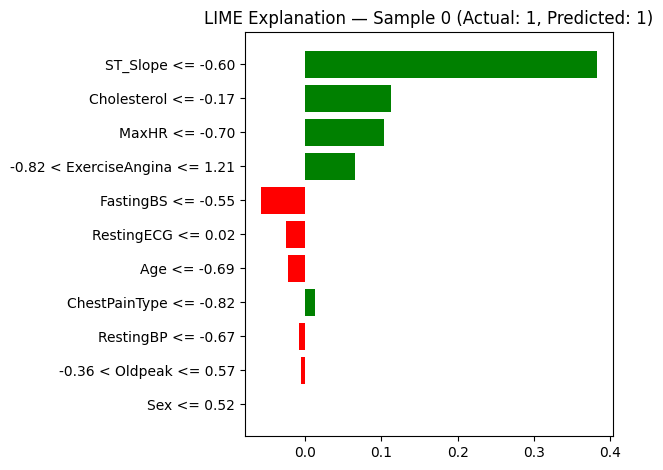


LIME Explanation for Sample 0:
  ST_Slope <= -0.60: 0.3822
  Cholesterol <= -0.17: 0.1125
  MaxHR <= -0.70: 0.1037
  -0.82 < ExerciseAngina <= 1.21: 0.0656
  FastingBS <= -0.55: -0.0570
  RestingECG <= 0.02: -0.0247
  Age <= -0.69: -0.0220
  ChestPainType <= -0.82: 0.0125
  RestingBP <= -0.67: -0.0073
  -0.36 < Oldpeak <= 0.57: -0.0047
  Sex <= 0.52: 0.0000


In [38]:
# LIME — Single Prediction Explanation 
 
# Create LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data  = X_train,
    feature_names  = X.columns.tolist(),
    class_names    = ['No Disease', 'Heart Disease'],
    mode           = 'classification',
    random_state   = 42
)

# Explain a single test instance (first one)
sample_idx  = 0
sample      = X_test[sample_idx]
explanation = lime_explainer.explain_instance(
    data_row       = sample,
    predict_fn     = rf.predict_proba,
    num_features   = len(X.columns)
)

# Plot
explanation.as_pyplot_figure()
plt.title(f'LIME Explanation — Sample {sample_idx} '
          f'(Actual: {y_test.values[sample_idx]}, '
          f'Predicted: {y_pred[sample_idx]})')
plt.tight_layout()
plt.show()

print(f"\nLIME Explanation for Sample {sample_idx}:")
for feat, weight in explanation.as_list():
    print(f"  {feat}: {weight:.4f}")

# *Partial Dependence Plots for Top 4 Features*

**Visualize PDP for the top 4 most important features to show how each feature affects prediction probability.**

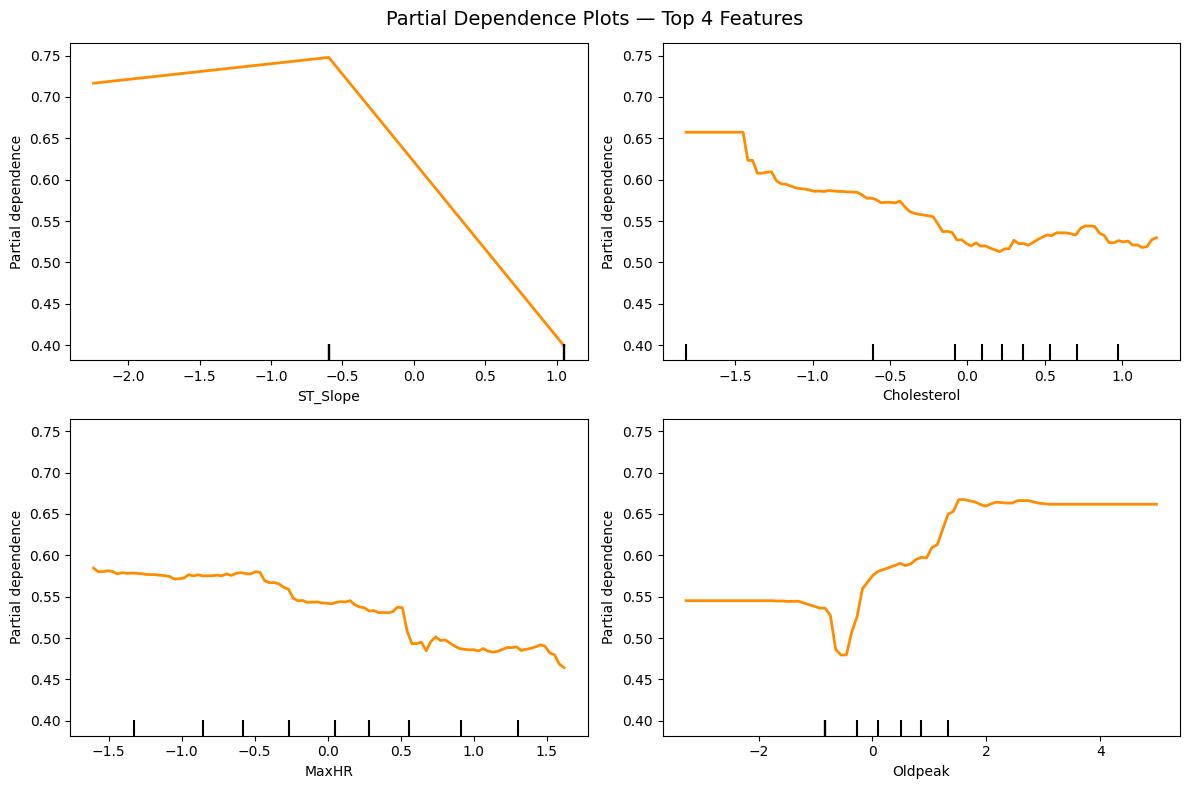

In [39]:
# Partial Dependence Plots

top4_features = feature_importance['Feature'].head(4).tolist()
top4_indices  = [list(X.columns).index(f) for f in top4_features]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    rf, X_scaled, top4_indices,
    feature_names = X.columns.tolist(),
    ax            = axes.flatten()[:4],
    line_kw       = {'color': 'darkorange', 'lw': 2}
)

plt.suptitle('Partial Dependence Plots — Top 4 Features', fontsize=14)
plt.tight_layout()
plt.show()

# *Feature Interaction Visualization*

**Show 2D PDP interaction plot between top 2 features to visualize how two features interact to affect prediction.**

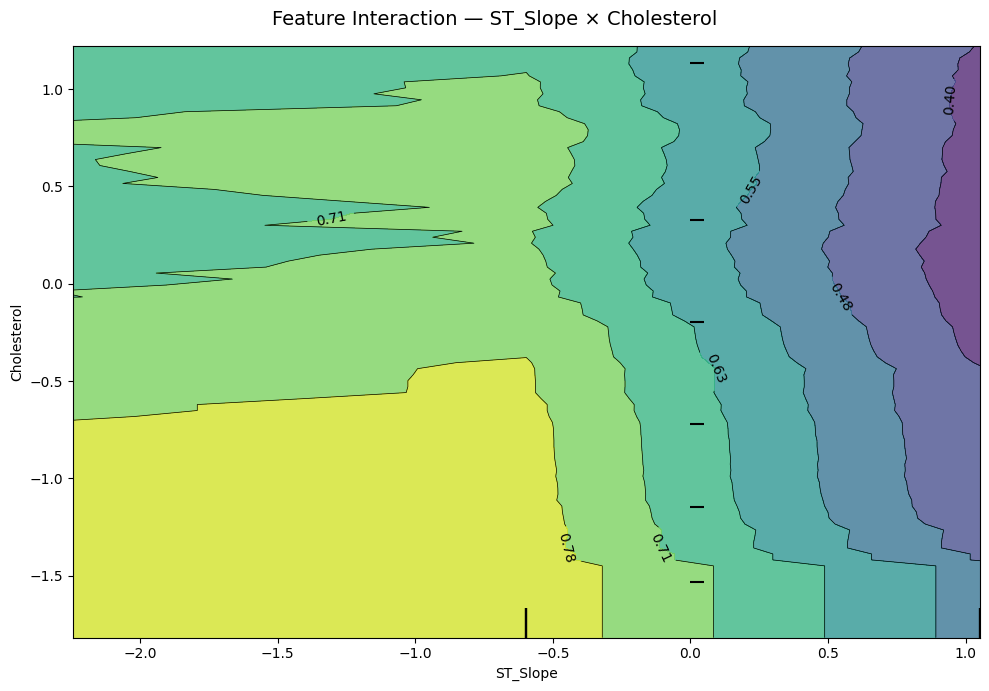

In [40]:
# Feature Interaction Visualization

top2_features = feature_importance['Feature'].head(2).tolist()
top2_indices  = [list(X.columns).index(f) for f in top2_features]

fig, ax = plt.subplots(figsize=(10, 7))

PartialDependenceDisplay.from_estimator(
    rf, X_scaled,
    features      = [tuple(top2_indices)],
    feature_names = X.columns.tolist(),
    ax            = ax,
    kind          = 'average'
)

plt.suptitle(f'Feature Interaction — {top2_features[0]} × {top2_features[1]}',
             fontsize=14)
plt.tight_layout()
plt.show()

# **Dash App Layout**

**Build Dash app layout using the following core Dash components with no external dependencies to be clean and simple.**

 - EDA
 - Preprocessing
 - Model Evaluation
 - Clustering
 - Interpretability
 - Uploading Datasets

In [41]:
# Dash App Layout

app = dash.Dash(__name__)
app.title = 'ML Workflow Dashboard — Heart Disease'

num_options = [{'label': col, 'value': col} for col in num_cols]

app.layout = html.Div([

    # ── Header ──────────────────────────────────────────────
    html.H2('ML Workflow Dashboard — Heart Disease Prediction',
            style={'textAlign': 'center', 'marginTop': '20px'}),
    html.P('EDA · Preprocessing · Model Evaluation · Clustering · Interpretability',
           style={'textAlign': 'center', 'color': 'gray'}),
    html.Hr(),

    # ── Tabs ────────────────────────────────────────────────
    dcc.Tabs([

        # --- Tab 1: EDA ---
        dcc.Tab(label='📊 EDA', children=[

            html.Div([
                html.Div([
                    html.Label('Select Feature:'),
                    dcc.Dropdown(id='eda-feature',
                                 options=num_options,
                                 value=num_cols[0],
                                 clearable=False),

                    html.Br(),

                    html.Label('Chart Type:'),
                    dcc.RadioItems(
                        id='eda-chart-type',
                        options=[
                            {'label': 'Histogram', 'value': 'histogram'},
                            {'label': 'Box Plot', 'value': 'box'},
                        ],
                        value='histogram',
                        labelStyle={'display': 'inline-block',
                                    'marginRight': '15px'}
                    ),
                ], style={'width': '25%', 'display': 'inline-block',
                          'verticalAlign': 'top', 'padding': '20px'}),

                html.Div([dcc.Graph(id='eda-chart')],
                         style={'width': '73%', 'display': 'inline-block'})
            ]),

            html.Hr(),

            html.H4('Scatter Plot', style={'padding': '10px 20px'}),

            html.Div([
                html.Div([
                    html.Label('X Axis:'),
                    dcc.Dropdown(id='scatter-x',
                                 options=num_options,
                                 value=num_cols[0],
                                 clearable=False),

                    html.Br(),

                    html.Label('Y Axis:'),
                    dcc.Dropdown(id='scatter-y',
                                 options=num_options,
                                 value=num_cols[1],
                                 clearable=False),
                ], style={'width': '25%', 'display': 'inline-block',
                          'verticalAlign': 'top', 'padding': '20px'}),

                html.Div([dcc.Graph(id='scatter-chart')],
                         style={'width': '73%', 'display': 'inline-block'})
            ]),

            html.Hr(),
            html.H4('Correlation Matrix', style={'padding': '10px 20px'}),
            dcc.Graph(id='corr-matrix'),
        ]),

        # --- Tab 2 ---
        dcc.Tab(label='⚙️ Preprocessing', children=[
            html.Div([
                html.Div([
                    html.Label('Select Feature:'),
                    dcc.Dropdown(id='preprocess-feature',
                                 options=num_options,
                                 value=num_cols[0],
                                 clearable=False),
                ], style={'width': '25%', 'display': 'inline-block',
                          'verticalAlign': 'top', 'padding': '20px'}),

                html.Div([dcc.Graph(id='preprocess-chart')],
                         style={'width': '73%', 'display': 'inline-block'})
            ])
        ]),

        # --- Tab 3 ---
        dcc.Tab(label='🎯 Model Evaluation', children=[
            html.Div([
                html.Div([dcc.Graph(id='conf-matrix')],
                         style={'width': '50%', 'display': 'inline-block'}),
                html.Div([dcc.Graph(id='roc-curve')],
                         style={'width': '50%', 'display': 'inline-block'}),
            ]),
            html.Div([
                html.Div([dcc.Graph(id='pr-curve')],
                         style={'width': '50%', 'display': 'inline-block'}),
                html.Div([dcc.Graph(id='feat-importance')],
                         style={'width': '50%', 'display': 'inline-block'}),
            ])
        ]),

        # --- Tab 4 ---
        dcc.Tab(label='🔵 Clustering', children=[
            html.Div([
                html.Div([dcc.Graph(id='pca-cluster')],
                         style={'width': '70%', 'display': 'inline-block'}),
                html.Div([dcc.Graph(id='elbow-plot')],
                         style={'width': '30%', 'display': 'inline-block'}),
            ])
        ]),

        # --- Tab 5 ---
        dcc.Tab(label='🔍 Interpretability', children=[

            html.Div([
                html.Label('Number of Top Features:'),
                dcc.Slider(id='shap-slider',
                           min=3, max=len(X.columns),
                           step=1, value=8,
                           marks={i: str(i)
                                  for i in range(3, len(X.columns)+1, 2)}),
            ], style={'padding': '20px'}),

            dcc.Graph(id='shap-chart'),

            html.Hr(),

            html.Div([
                html.Label('Select Feature for Dependence Plot:'),
                dcc.Dropdown(id='shap-dep-feature',
                             options=[{'label': col, 'value': col}
                                      for col in X.columns],
                             value=top_feature_name,
                             clearable=False),
            ], style={'padding': '20px', 'width': '30%'}),

            dcc.Graph(id='shap-dependence'),

            html.Hr(),

            html.H4('Decision Boundary — Top 2 SHAP Features',
                    style={'padding': '10px 20px'}),

            dcc.Graph(id='decision-boundary'),
        ]),

        # --- Tab 6 ---
        dcc.Tab(label='📁 Upload Dataset', children=[
            html.Div([
                html.H4('Upload Your Own Dataset',
                        style={'textAlign': 'center', 'marginTop': '20px'}),

                html.P('Upload a CSV file to explore your own data.',
                       style={'textAlign': 'center', 'color': 'gray'}),

                dcc.Upload(
                    id='upload-data',
                    children=html.Div([
                        'Drag and Drop or ',
                        html.A('Select a CSV File')
                    ]),
                    style={
                        'width': '60%',
                        'height': '60px',
                        'lineHeight': '60px',
                        'borderWidth': '2px',
                        'borderStyle': 'dashed',
                        'borderRadius': '5px',
                        'textAlign': 'center',
                        'margin': '20px auto',
                        'cursor': 'pointer',
                    },
                    multiple=False
                ),

                html.Div(id='upload-output')
            ])
        ])

    ])

], style={'fontFamily': 'Arial', 'maxWidth': '1400px', 'margin': 'auto'})

print("Layout defined")

Layout defined


# **Callbacks**

**Wire all callbacks to make the dashboard interactive by making each dropdown/slider triggers a plot update to connect user inputs to plot outputs.**

In [42]:
# Callbacks

# ── EDA: Histogram / Box ────────────────────────────────────
@app.callback(
    Output('eda-chart', 'figure'),
    [Input('eda-feature', 'value'),
     Input('eda-chart-type', 'value')]
)
def update_eda_chart(feature, chart_type):
    dff = df.copy()
    dff['HeartDisease'] = dff['HeartDisease'].map({0: 'No Disease',
                                                    1: 'Heart Disease'})
    if chart_type == 'histogram':
        fig = px.histogram(dff, x=feature, color='HeartDisease',
                           barmode='overlay', opacity=0.7,
                           color_discrete_sequence=px.colors.qualitative.Set2,
                           title=f'Histogram — {feature}')
    else:
        fig = px.box(dff, x='HeartDisease', y=feature,
                     color='HeartDisease',
                     color_discrete_sequence=px.colors.qualitative.Set2,
                     title=f'Box Plot — {feature}')
    fig.update_layout(plot_bgcolor='white', height=450)
    return fig


# ── EDA: Scatter ─────────────────────────────────────────────
@app.callback(
    Output('scatter-chart', 'figure'),
    [Input('scatter-x', 'value'),
     Input('scatter-y', 'value')]
)
def update_scatter(x_col, y_col):
    dff = df.copy()
    dff['HeartDisease'] = dff['HeartDisease'].map({0: 'No Disease',
                                                    1: 'Heart Disease'})
    fig = px.scatter(dff, x=x_col, y=y_col,
                     color='HeartDisease',
                     color_discrete_sequence=px.colors.qualitative.Set2,
                     opacity=0.7,
                     title=f'Scatter — {x_col} vs {y_col}')
    fig.update_layout(plot_bgcolor='white', height=450)
    return fig


# ── EDA: Correlation Matrix ──────────────────────────────────
@app.callback(
    Output('corr-matrix', 'figure'),
    Input('eda-feature', 'value')
)
def update_corr(_):
    corr = df[num_cols + ['HeartDisease']].corr().round(2)
    fig  = px.imshow(corr, text_auto=True,
                     color_continuous_scale='Blues',
                     title='Correlation Matrix')
    fig.update_layout(height=500)
    return fig


# ── Preprocessing: Before/After ──────────────────────────────
@app.callback(
    Output('preprocess-chart', 'figure'),
    Input('preprocess-feature', 'value')
)
def update_preprocess(feature):
    col_idx = list(X.columns).index(feature)
    before  = X[feature].values
    after   = X_scaled[:, col_idx]

    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=[f'{feature} — Before Scaling',
                                        f'{feature} — After Scaling'])
    fig.add_trace(go.Histogram(x=before, marker_color='steelblue',
                               opacity=0.7, name='Before'), row=1, col=1)
    fig.add_trace(go.Histogram(x=after,  marker_color='darkorange',
                               opacity=0.7, name='After'),  row=1, col=2)
    fig.update_layout(plot_bgcolor='white', height=450,
                      title=f'Before vs After StandardScaler — {feature}',
                      showlegend=False)
    return fig


# ── Model Evaluation: Confusion Matrix ───────────────────────
@app.callback(
    Output('conf-matrix', 'figure'),
    Input('eda-feature', 'value')
)
def update_conf_matrix(_):
    cm     = confusion_matrix(y_test, y_pred)
    labels = ['No Disease', 'Heart Disease']
    fig    = px.imshow(cm, text_auto=True,
                       color_continuous_scale='Blues',
                       x=labels, y=labels,
                       title='Confusion Matrix')
    fig.update_layout(height=400)
    return fig


# ── Model Evaluation: ROC Curve ──────────────────────────────
@app.callback(
    Output('roc-curve', 'figure'),
    Input('eda-feature', 'value')
)
def update_roc(_):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc     = auc(fpr, tpr)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines',
                             line=dict(color='darkorange', width=2),
                             name=f'AUC = {roc_auc:.2f}'))
    fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines',
                             line=dict(color='navy', dash='dash'),
                             name='Baseline'))
    fig.update_layout(plot_bgcolor='white', height=400,
                      title='ROC Curve',
                      xaxis_title='False Positive Rate',
                      yaxis_title='True Positive Rate')
    return fig


# ── Model Evaluation: PR Curve ───────────────────────────────
@app.callback(
    Output('pr-curve', 'figure'),
    Input('eda-feature', 'value')
)
def update_pr(_):
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=recall, y=precision, mode='lines',
                             line=dict(color='darkorange', width=2),
                             name=f'AUC = {pr_auc:.2f}'))
    fig.add_shape(type='line', x0=0, x1=1,
                  y0=y_test.mean(), y1=y_test.mean(),
                  line=dict(color='navy', dash='dash'))
    fig.update_layout(plot_bgcolor='white', height=400,
                      title='Precision-Recall Curve',
                      xaxis_title='Recall',
                      yaxis_title='Precision')
    return fig


# ── Model Evaluation: Feature Importance ─────────────────────
@app.callback(
    Output('feat-importance', 'figure'),
    Input('eda-feature', 'value')
)
def update_feat_importance(_):
    fig = px.bar(feature_importance.sort_values('Importance'),
                 x='Importance', y='Feature',
                 orientation='h',
                 color='Importance',
                 color_continuous_scale='Blues',
                 title='Feature Importance — Random Forest')
    fig.update_layout(plot_bgcolor='white', height=400)
    return fig


# ── Clustering: PCA 3D ───────────────────────────────────────
@app.callback(
    Output('pca-cluster', 'figure'),
    Input('eda-feature', 'value')
)
def update_pca(_):
    fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                        color='Cluster',
                        color_discrete_sequence=px.colors.qualitative.Set2,
                        title=f'KMeans Clusters — PCA 3D '
                              f'({pca.explained_variance_ratio_.sum()*100:.1f}% variance)',
                        opacity=0.7)
    fig.update_layout(height=550)
    return fig


# ── Clustering: Elbow Plot ───────────────────────────────────
@app.callback(
    Output('elbow-plot', 'figure'),
    Input('eda-feature', 'value')
)
def update_elbow(_):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=list(k_range), y=inertia,
                             mode='lines+markers',
                             line=dict(color='darkorange', width=2),
                             marker=dict(size=8)))
    fig.update_layout(plot_bgcolor='white', height=550,
                      title='Elbow Plot — Optimal K',
                      xaxis_title='Number of Clusters (K)',
                      yaxis_title='Inertia')
    return fig


# ── Interpretability: SHAP Bar ───────────────────────────────
@app.callback(
    Output('shap-chart', 'figure'),
    Input('shap-slider', 'value')
)
def update_shap(top_n):
    sv_class1 = sv[:, :, 1]
    shap_imp  = pd.DataFrame({
        'Feature'   : X.columns.tolist(),
        'Importance': np.abs(sv_class1).mean(axis=0)
    }).sort_values('Importance', ascending=False).head(top_n)

    fig = px.bar(shap_imp.sort_values('Importance'),
                 x='Importance', y='Feature',
                 orientation='h',
                 color='Importance',
                 color_continuous_scale='Blues',
                 title=f'Top {top_n} Features — SHAP Importance')
    fig.update_layout(plot_bgcolor='white', height=500,
                      xaxis_title='Mean |SHAP Value|',
                      yaxis_title='Feature')
    return fig


# ── Interpretability: SHAP Dependence ────────────────────────
@app.callback(
    Output('shap-dependence', 'figure'),
    Input('shap-dep-feature', 'value')
)
def update_shap_dependence(feature):
    sv_class1 = sv[:, :, 1]
    feat_idx  = list(X.columns).index(feature)
    feat_vals = X_sample[feature].values
    shap_vals = sv_class1[:, feat_idx]

    fig = px.scatter(x=feat_vals, y=shap_vals,
                     labels={'x': feature, 'y': 'SHAP Value'},
                     title=f'SHAP Dependence Plot — {feature}',
                     color=shap_vals,
                     color_continuous_scale='Blues')
    fig.add_hline(y=0, line_dash='dash', line_color='navy')
    fig.update_layout(plot_bgcolor='white', height=450)
    return fig


# ── Interpretability: Decision Boundary ──────────────────────
@app.callback(
    Output('decision-boundary', 'figure'),
    Input('shap-slider', 'value')
)
def update_decision_boundary(_):
    sv_class1    = sv[:, :, 1]
    top2_indices = np.argsort(np.abs(sv_class1).mean(axis=0))[-2:]
    top2_names   = X.columns[top2_indices].tolist()

    X_train_2d = X_train[:, top2_indices]
    X_test_2d  = X_test[:, top2_indices]

    rf_2d = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_2d.fit(X_train_2d, y_train)

    x_min, x_max = X_train_2d[:, 0].min()-1, X_train_2d[:, 0].max()+1
    y_min, y_max = X_train_2d[:, 1].min()-1, X_train_2d[:, 1].max()+1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    X_plot = X_test_2d[:200]
    y_plot = y_test.values[:200]

    fig = go.Figure()
    fig.add_trace(go.Contour(x=np.arange(x_min, x_max, 0.1),
                             y=np.arange(y_min, y_max, 0.1),
                             z=Z, opacity=0.4,
                             colorscale='RdBu',
                             showscale=False))
    fig.add_trace(go.Scatter(
        x=X_plot[y_plot==0, 0], y=X_plot[y_plot==0, 1],
        mode='markers',
        marker=dict(color='steelblue', size=6,
                    line=dict(color='black', width=0.5)),
        name='No Disease'))
    fig.add_trace(go.Scatter(
        x=X_plot[y_plot==1, 0], y=X_plot[y_plot==1, 1],
        mode='markers',
        marker=dict(color='darkorange', size=6,
                    line=dict(color='black', width=0.5)),
        name='Heart Disease'))
    fig.update_layout(plot_bgcolor='white', height=500,
                      title=f'Decision Boundary — Top 2 SHAP Features: {top2_names}',
                      xaxis_title=top2_names[0],
                      yaxis_title=top2_names[1])
    return fig

# ── Upload Dataset ───────────────────────────────────────────

@app.callback(
    Output('upload-output', 'children'),
    Input('upload-data', 'contents'),
    State('upload-data', 'filename')
)
def upload_dataset(contents, filename):
    if contents is None:
        return html.P('No file uploaded yet.',
                      style={'textAlign': 'center', 'color': 'gray'})

    # Decode uploaded file
    content_type, content_string = contents.split(',')
    decoded = base64.b64decode(content_string)

    try:
        uploaded_df = pd.read_csv(io.StringIO(decoded.decode('utf-8')))

        return html.Div([
            html.H5(f'✅ File uploaded: {filename}',
                    style={'textAlign': 'center', 'color': 'green'}),
            html.P(f'Shape: {uploaded_df.shape[0]} rows × {uploaded_df.shape[1]} columns',
                   style={'textAlign': 'center'}),
            html.P(f'Columns: {uploaded_df.columns.tolist()}',
                   style={'textAlign': 'center', 'color': 'gray'}),
            dash_table.DataTable(
                data    = uploaded_df.head(10).to_dict('records'),
                columns = [{'name': c, 'id': c} for c in uploaded_df.columns],
                style_table    = {'overflowX': 'auto', 'margin': '20px'},
                style_cell     = {'textAlign': 'left', 'padding': '8px'},
                style_header   = {'backgroundColor': 'steelblue',
                                  'color': 'white', 'fontWeight': 'bold'}
            )
        ])
    except Exception as e:
        return html.P(f'❌ Error reading file: {str(e)}',
                      style={'textAlign': 'center', 'color': 'red'})
print("All callbacks defined")

All callbacks defined


**Launch the Dash app to open interactive dashboard in browser** at **http://127.0.0.1:8050/**

In [43]:
# Run the App

if __name__ == '__main__':
    app.run(debug=False, port=8050)